# 批量因子回测 Notebook对指定目录下的多张因子表进行批量回测。支持：- **一个或多个表**回测（通过文件名列表或 glob 模式）- **切换目录**（修改 `FACTOR_DIR` 即可）- 自定义回测参数（`display`、`if_trade_tmr`、`specific_return`、`return_type`）每张表回测前会标注表名，`display=True` 会展示完整图表。最后输出汇总对比表。---## 当前配置| 参数 | 值 ||------|-----|| `if_trade_tmr` | `True` || `specific_return` | `False` || `return_type` | `"Vwap"` || 日期范围 | `2020.01.03 ~ 2025.05.01` || 目录 | `subspace_factors_full` 下的 14 张 sum 表 |

In [1]:
import pandas as pd
from tqdm import tqdm
import os
import datetime as dt
import sys
import glob
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display as ipy_display, Markdown, HTML

In [2]:
# ---- mfrt 环境 ----
sys.path.append("/data/workspace/libs/pytools")
db_dir = "/data/workspace/Data/DataBase"

from mfrt.research_tools import DBTool
from mfrt.opt_backtest import OptBacktest
from mfrt.eval_netvalue import EvalNetValue
from mfrt.eval_factor import EvalFactor

opt_bt = OptBacktest(db_dir)
eval_NV = EvalNetValue(db_dir)
eval_F  = EvalFactor(db_dir)

check_Barra_list = ('BETA', 'MOMENTUM', 'SIZE', 'RESVOL', 'BTOP',
                    'LIQUIDTY', 'SPRET', 'SIZENL', 'GROWTH', 'LEVERAGE')

def test_factor(factor: pd.DataFrame,
                start_dt,
                end_dt,
                display: bool = False,
                if_trade_tmr: bool = True,
                specific_return: bool = True,
                Universe=None,
                return_type: str = 'Vwap'):
    """调用 EvalFactor.quick_test 进行回测并返回 F_Result 对象。"""
    F_res = eval_F.quick_test(
        factor, start_dt=start_dt, end_dt=end_dt,
        Group_Num=10, Horizon=10,
        Return_Type=return_type,
        Specific_Return=specific_return,
        Universe=Universe,
        check_Barra_list=check_Barra_list,
        extraExp_check_dict=None,
        if_trade_tmr=if_trade_tmr,
        display=display,
    )
    return F_res

## 配置区修改以下变量即可切换目录、调整表名或回测参数。

In [3]:
# ===================== 配置区 =====================
# 因子表目录（修改此处切换目录）
FACTOR_DIR = "/home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/gubapost_cls/subspace_factors_full"

# 表名匹配模式（glob）；设为 None 则用显式列表 TABLES
TABLE_PATTERN = "factor_sum_*.parquet"

# 也可显式指定文件名列表（优先级高于 glob 模式）
# TABLES = ["factor_sum_H.parquet", "factor_sum_L.parquet"]
TABLES = None

# ---- 回测参数 ----
DISPLAY         = True       # 展示图表
IF_TRADE_TMR    = True       # 次日交易
SPECIFIC_RETURN = False      # 不使用特异性收益
RETURN_TYPE     = "Vwap"    # 收益类型

# ---- 日期范围 ----
START_DT = "2020.01.03"
END_DT   = "2025.05.01"
# =================================================

In [4]:
def add_suffix(col_code):
    """自动添加后缀：6 开头加 .SH，其余加 .SZ。"""
    s = str(col_code)
    return s + ".SH" if s.startswith("6") else s + ".SZ"

def load_and_process(parquet_path):
    """读取 parquet → 过滤沪深A股 → 加后缀 → 转 datetime → 排序。"""
    fw = pd.read_parquet(parquet_path)
    if fw.index.name is None:
        fw.index.name = "date"

    # 只保留沪深 A 股：0/3 开头（深）+ 6 开头（沪）
    fw = fw[[c for c in fw.columns if str(c)[0] in "036"]]

    # 加后缀
    fw.columns = [add_suffix(c) for c in fw.columns]

    # 转 datetime
    fw.index = pd.to_datetime(fw.index, errors="coerce")
    fw = fw[fw.index.notna()]
    fw = fw.sort_index()

    print(f"  日期范围：{fw.index.min().date()} ~ {fw.index.max().date()}")
    print(f"  列数（沪深A股）：{len(fw.columns)}")
    return fw

In [5]:
# ============ 确定待回测表列表 ============
if TABLES is not None:
    table_files = [os.path.join(FACTOR_DIR, t) if not os.path.isabs(t) else t for t in TABLES]
else:
    table_files = sorted(glob.glob(os.path.join(FACTOR_DIR, TABLE_PATTERN)))

table_files = [t for t in table_files if t.endswith(".parquet")]

print(f"待回测表数：{len(table_files)}")
for i, f in enumerate(table_files):
    print(f"  {i+1:>2}. {os.path.basename(f)}")

待回测表数：14
   1. factor_sum_H.parquet
   2. factor_sum_L.parquet
   3. factor_sum_dead_01.parquet
   4. factor_sum_dead_02.parquet
   5. factor_sum_dead_03.parquet
   6. factor_sum_dead_04.parquet
   7. factor_sum_dead_05.parquet
   8. factor_sum_dead_06.parquet
   9. factor_sum_dead_07.parquet
  10. factor_sum_dead_08.parquet
  11. factor_sum_dead_09.parquet
  12. factor_sum_dead_10.parquet
  13. factor_sum_dead_11.parquet
  14. factor_sum_dead_12.parquet



---

## [1/14] 表名: `factor_sum_H`

文件: `factor_sum_H.parquet`  |  参数: if_trade_tmr=True, specific_return=False, return_type=Vwap


  日期范围：2020-01-02 ~ 2026-08-26
  列数（沪深A股）：5458


,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,-1.90%,-0.511,98.9%,20.7%,-9.6%,-2.41,-7.7%,-2.24


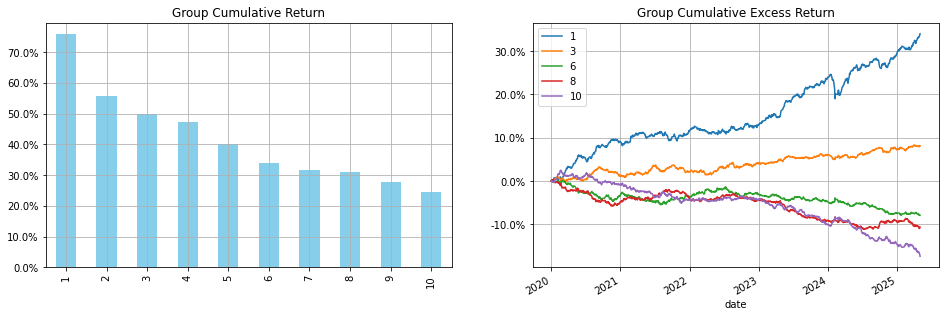

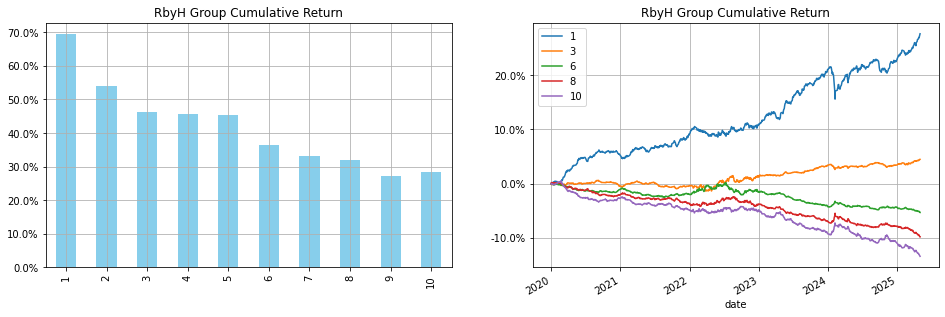

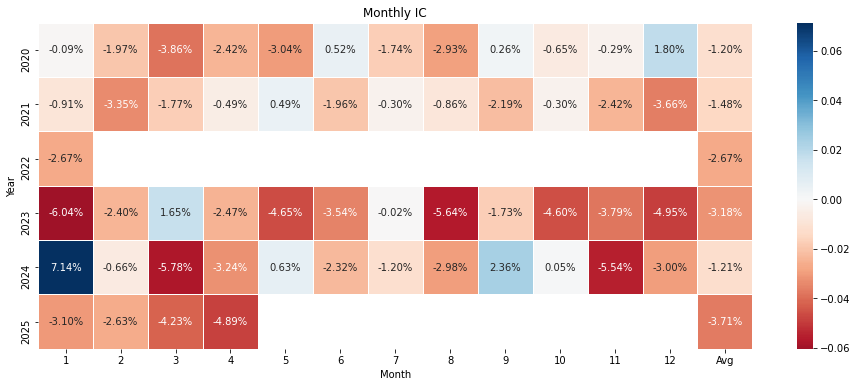

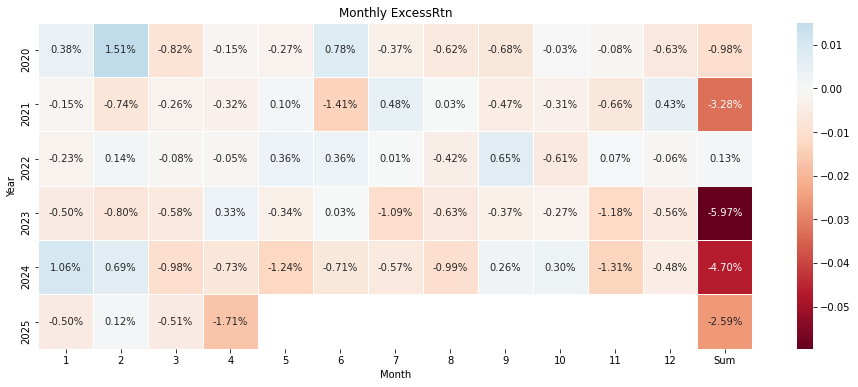

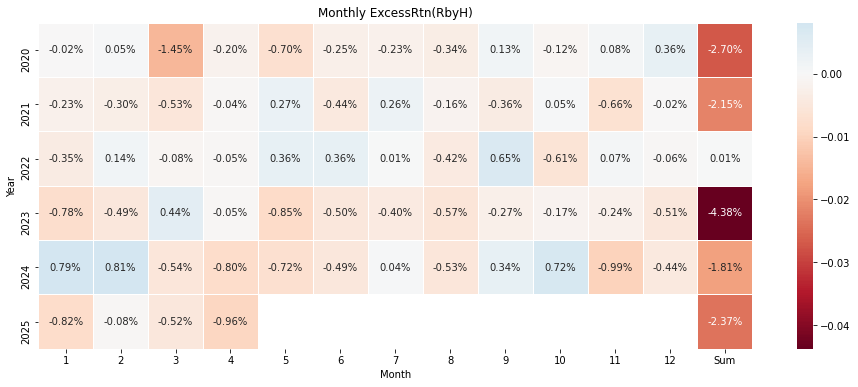

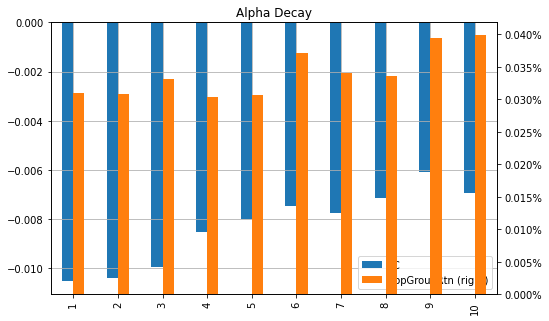

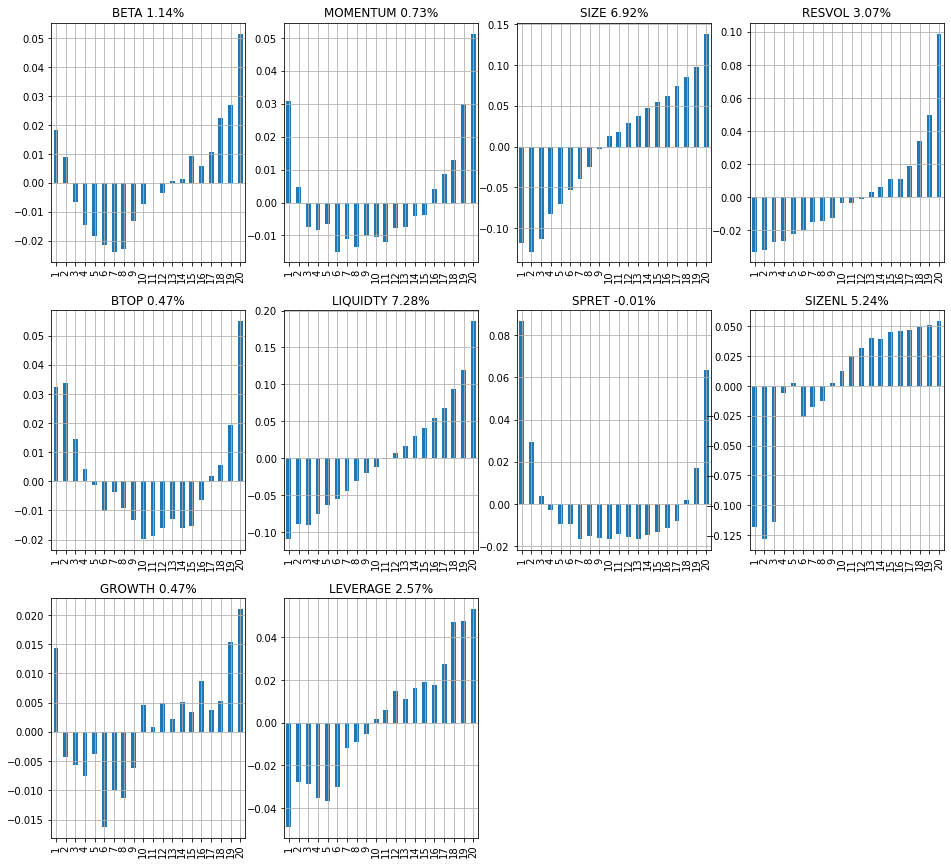


---

## [2/14] 表名: `factor_sum_L`

文件: `factor_sum_L.parquet`  |  参数: if_trade_tmr=True, specific_return=False, return_type=Vwap


  日期范围：2020-01-02 ~ 2026-08-26
  列数（沪深A股）：5458


,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,-1.91%,-0.512,98.9%,20.7%,-9.6%,-2.39,-7.7%,-2.27


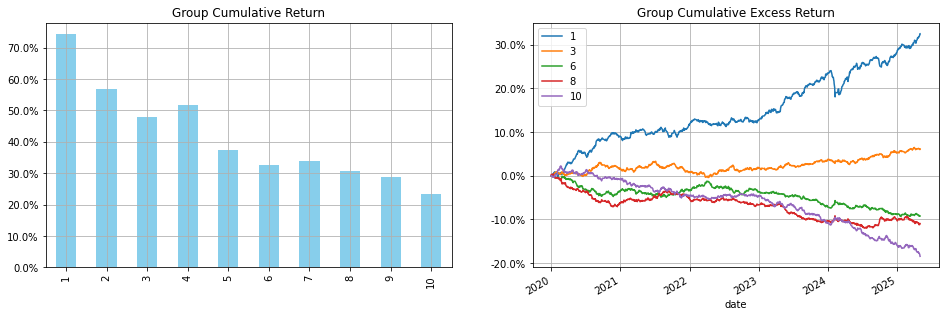

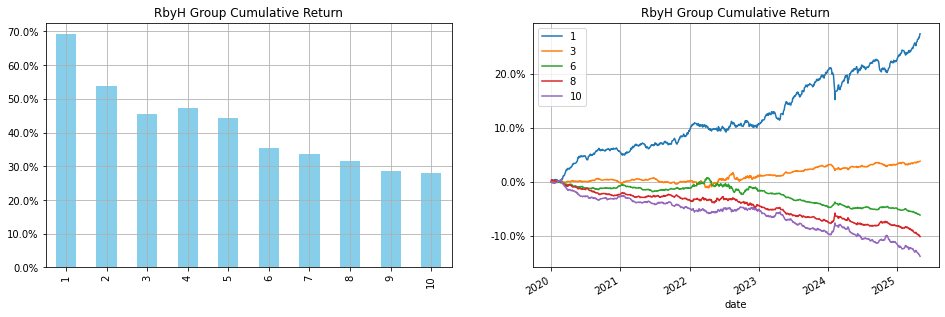

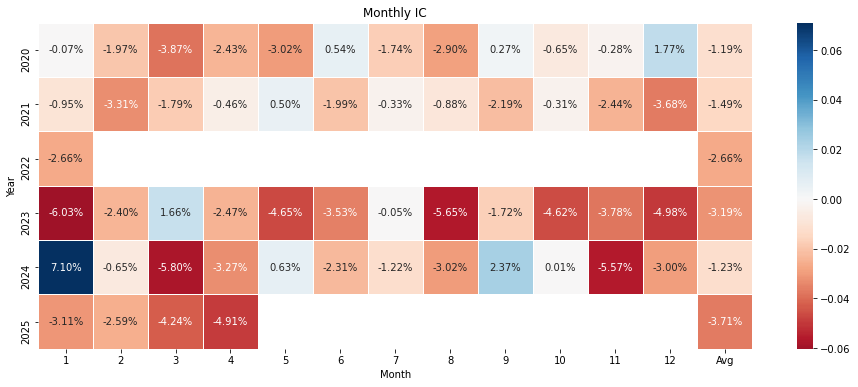

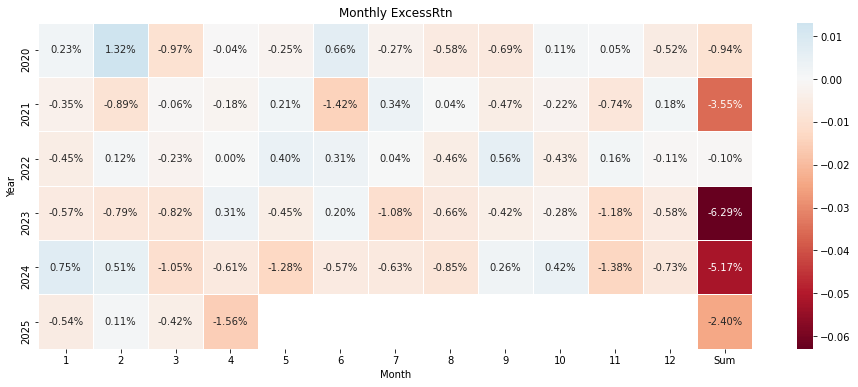

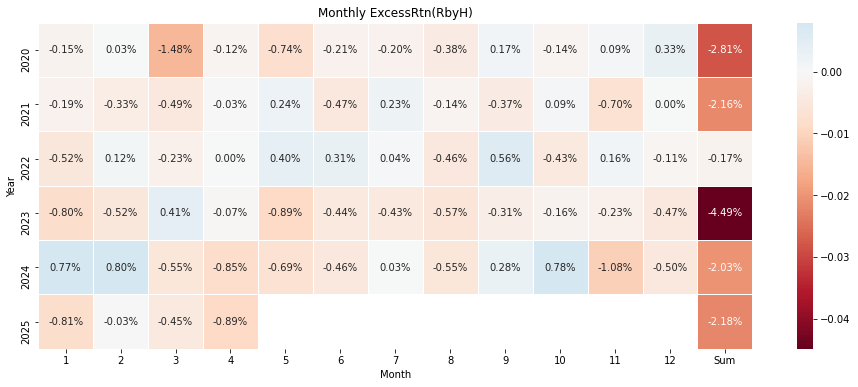

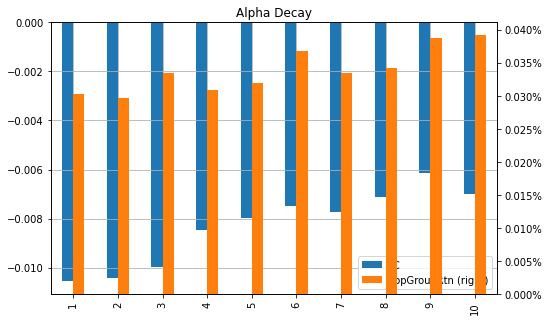

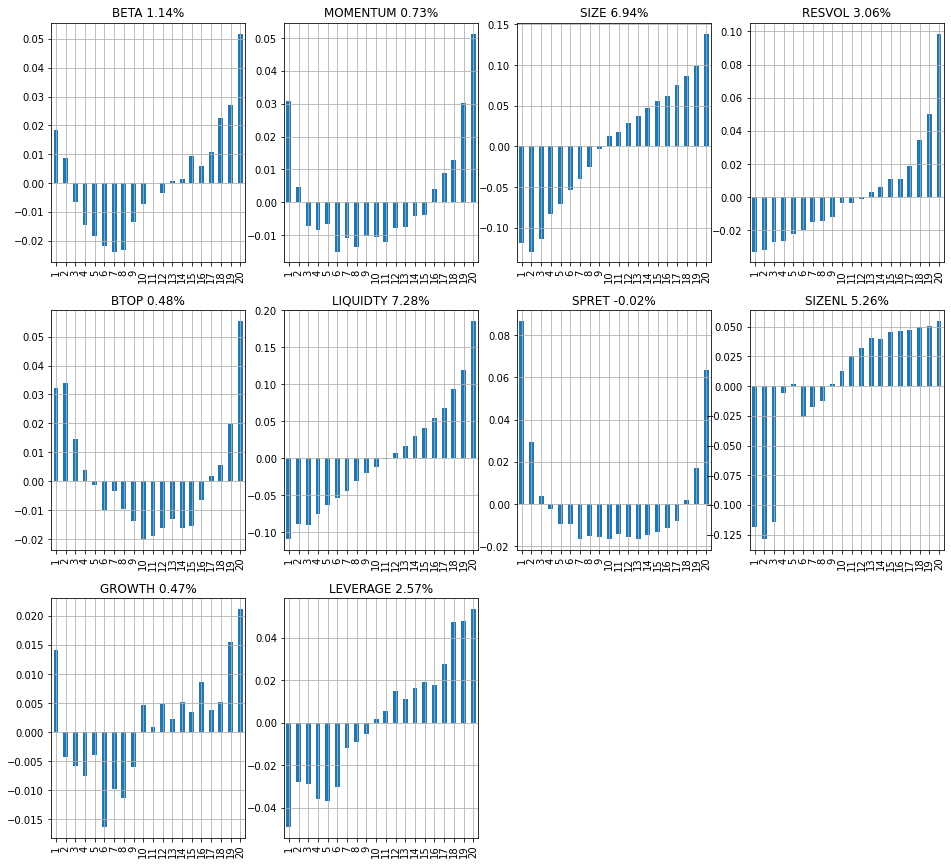


---

## [3/14] 表名: `factor_sum_dead_01`

文件: `factor_sum_dead_01.parquet`  |  参数: if_trade_tmr=True, specific_return=False, return_type=Vwap


  日期范围：2020-01-02 ~ 2026-08-26
  列数（沪深A股）：5458


,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,-1.91%,-0.512,98.9%,20.7%,-9.8%,-2.44,-7.7%,-2.25


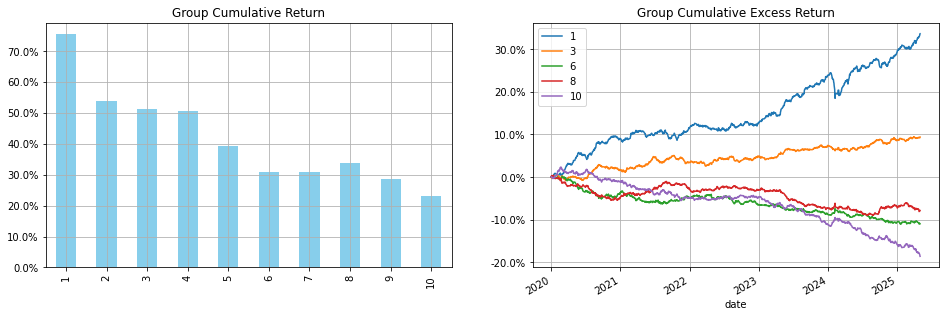

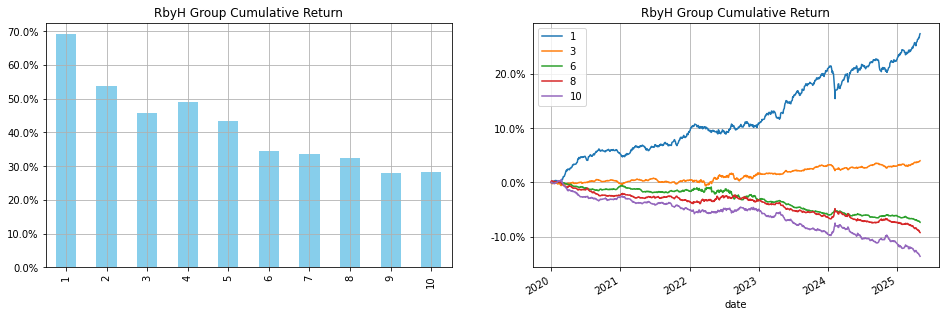

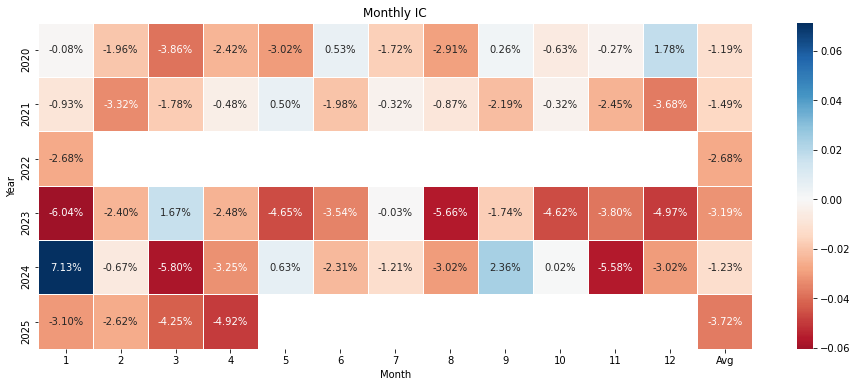

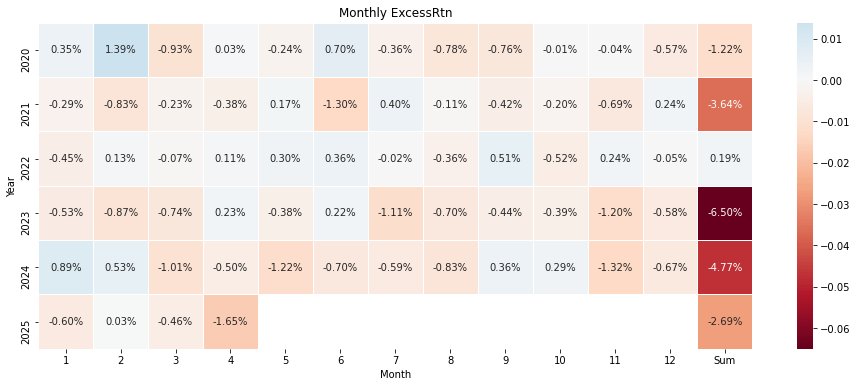

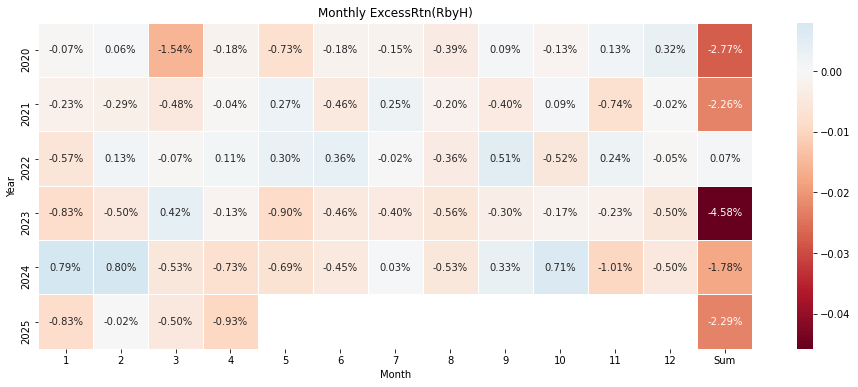

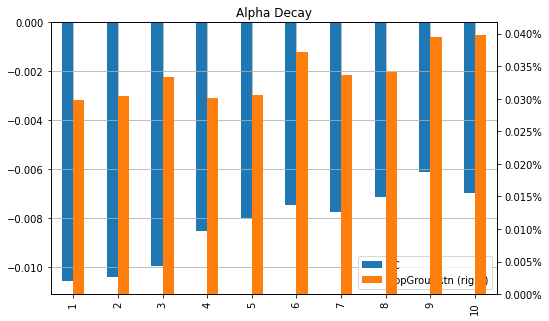

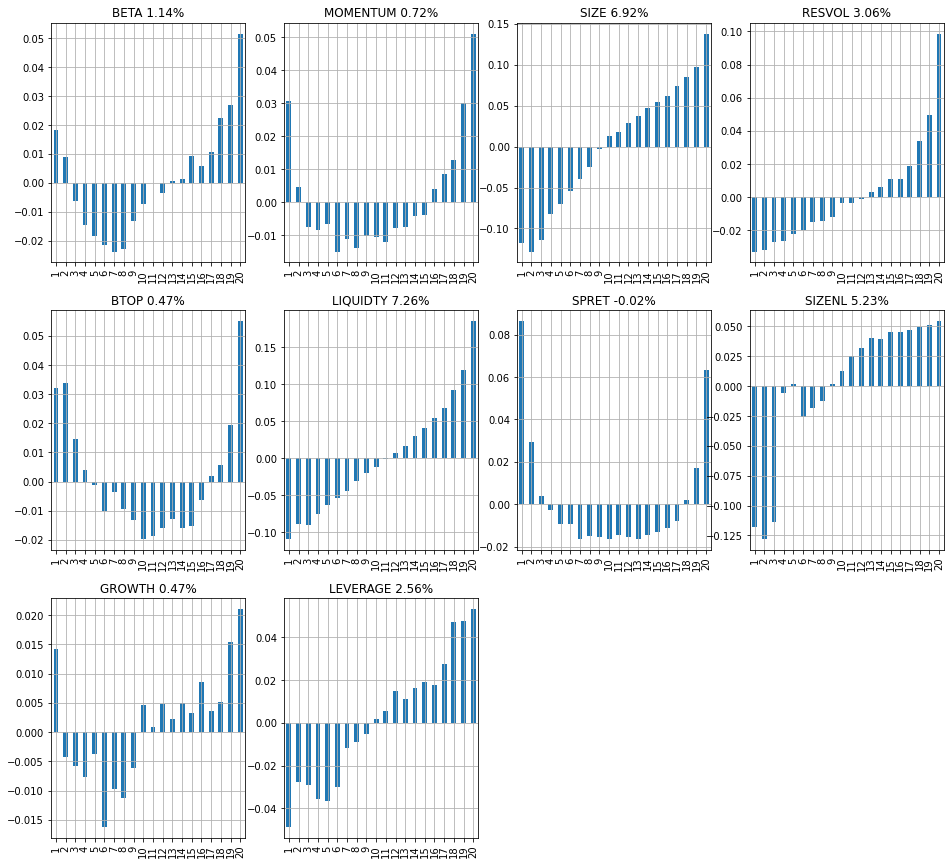


---

## [4/14] 表名: `factor_sum_dead_02`

文件: `factor_sum_dead_02.parquet`  |  参数: if_trade_tmr=True, specific_return=False, return_type=Vwap


  日期范围：2020-01-02 ~ 2026-08-26
  列数（沪深A股）：5458


,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,-1.91%,-0.511,98.9%,20.7%,-9.6%,-2.39,-7.7%,-2.24


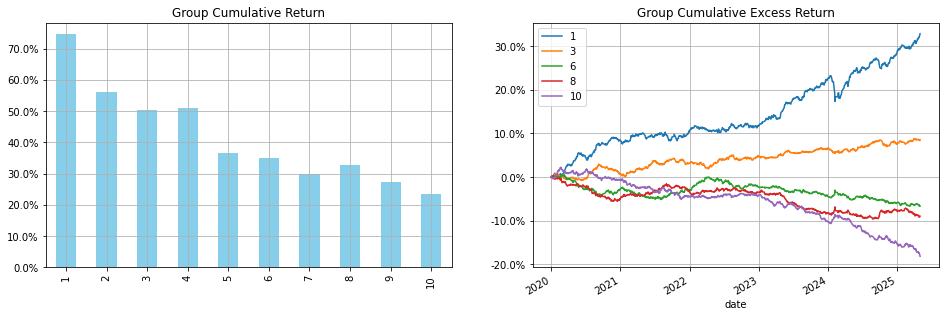

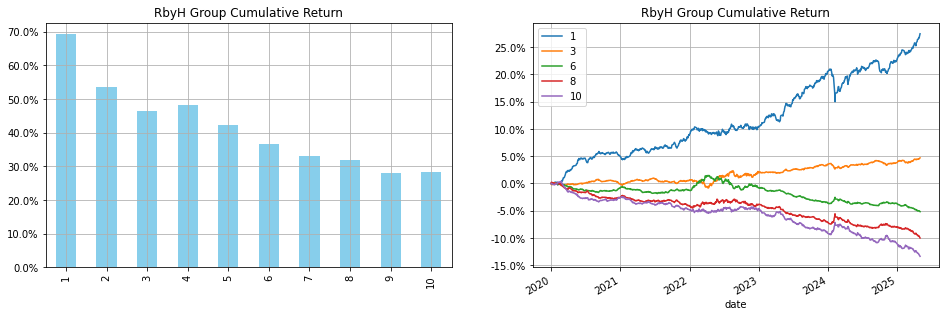

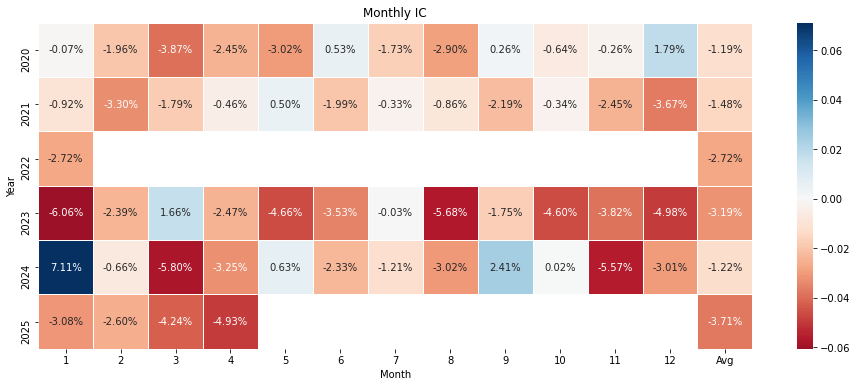

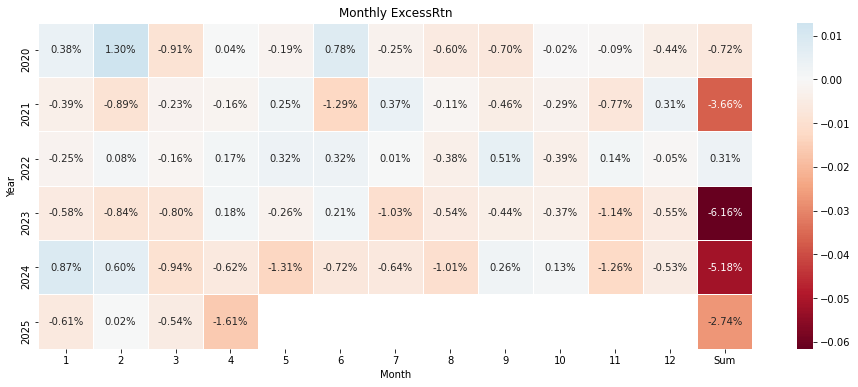

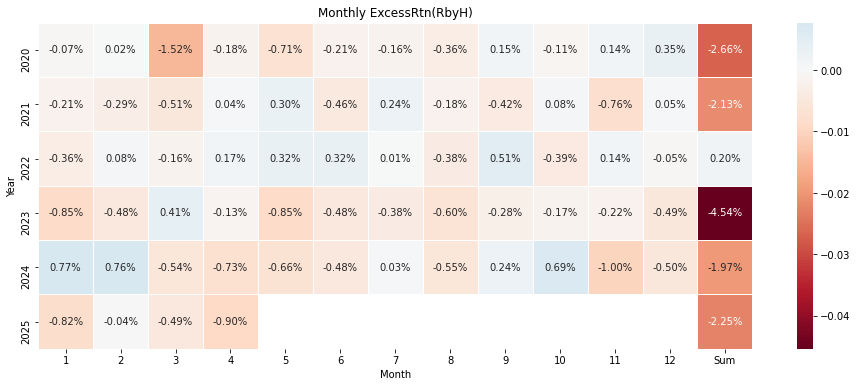

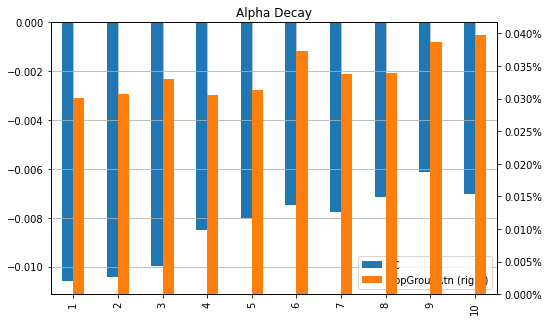

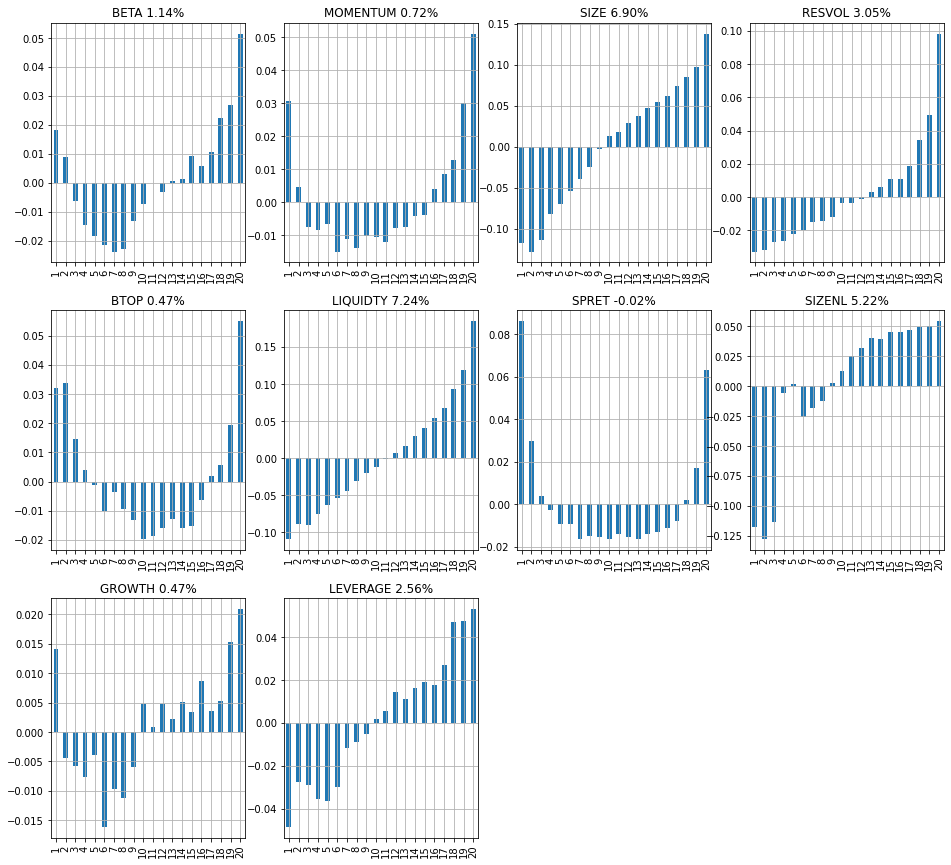


---

## [5/14] 表名: `factor_sum_dead_03`

文件: `factor_sum_dead_03.parquet`  |  参数: if_trade_tmr=True, specific_return=False, return_type=Vwap


  日期范围：2020-01-02 ~ 2026-08-26
  列数（沪深A股）：5458


,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,-1.91%,-0.512,98.9%,20.7%,-9.6%,-2.40,-7.7%,-2.26


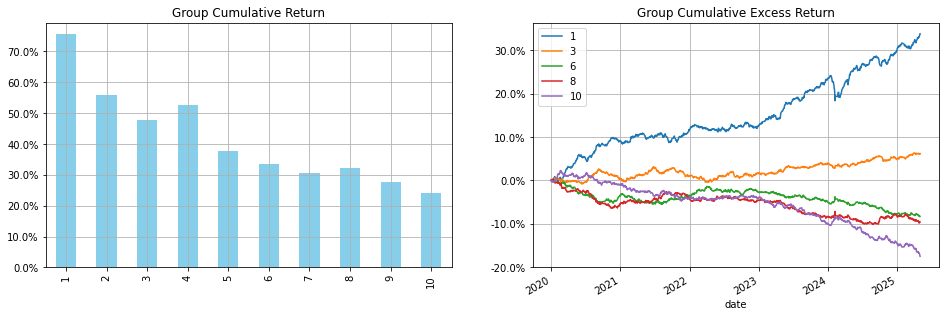

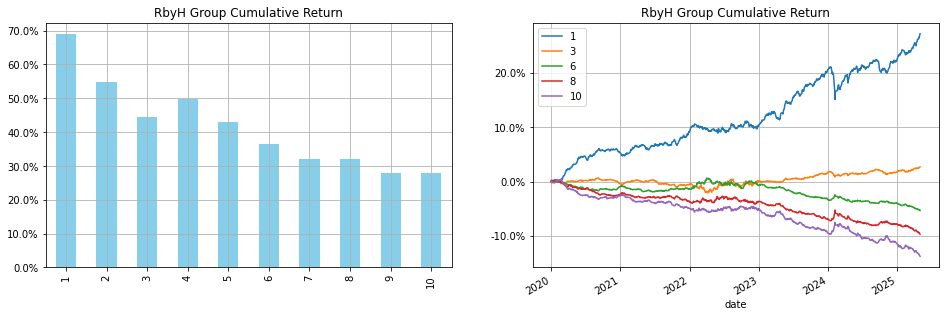

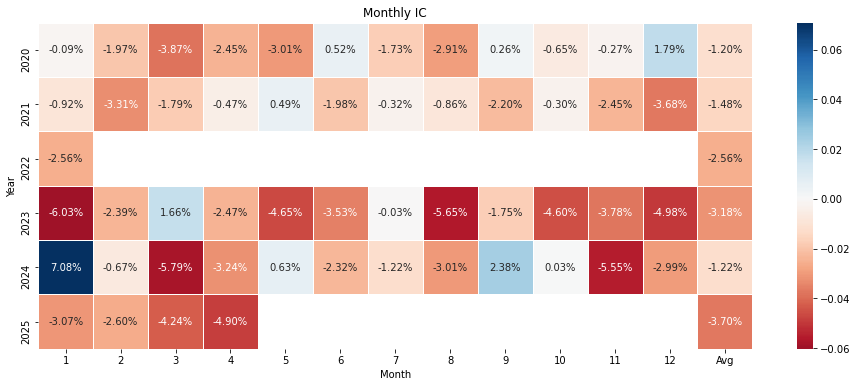

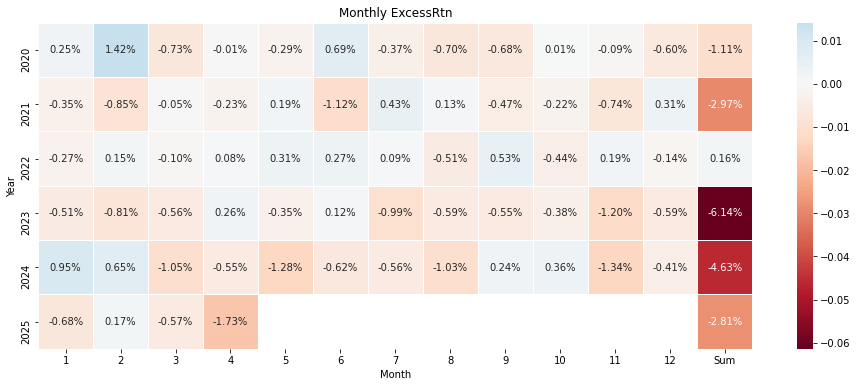

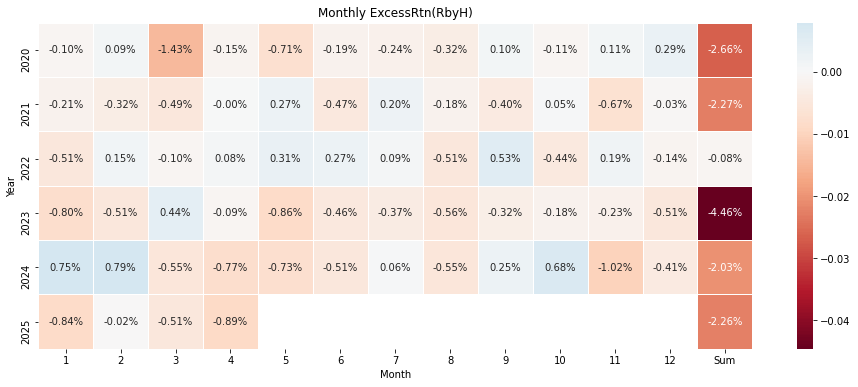

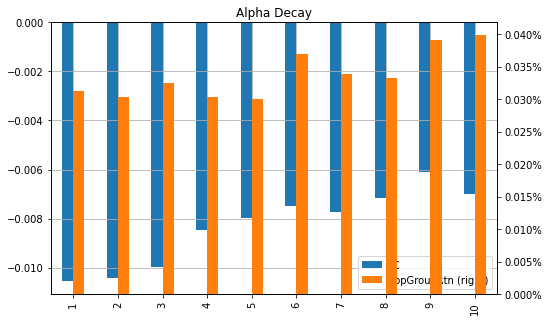

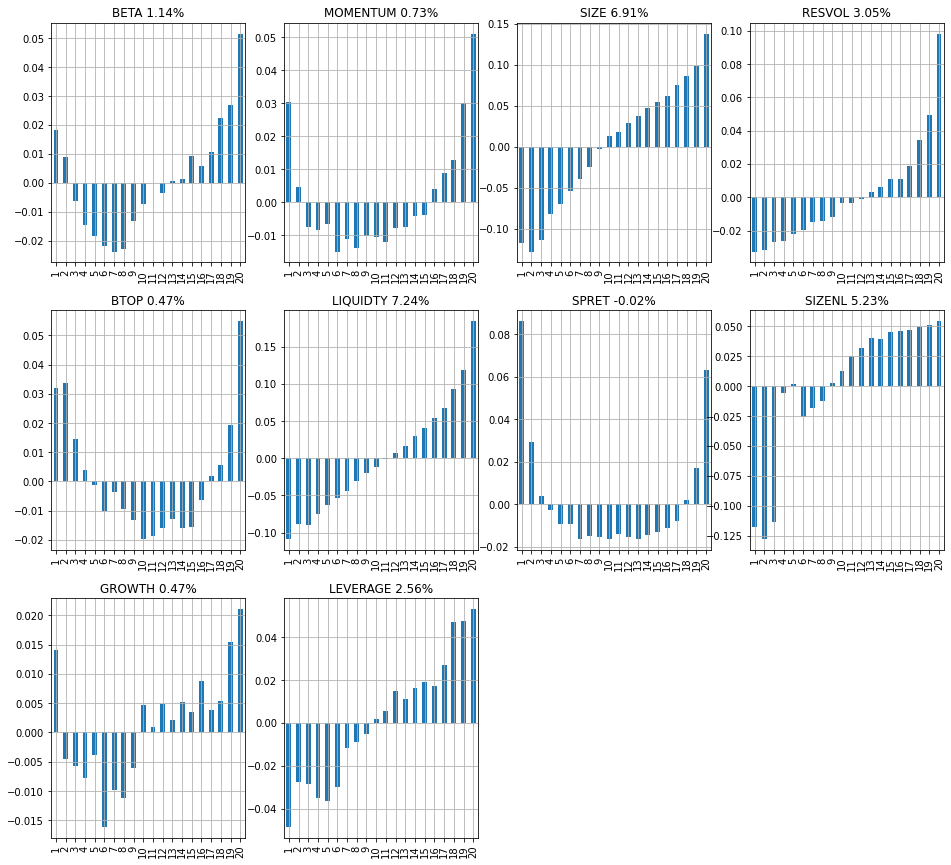


---

## [6/14] 表名: `factor_sum_dead_04`

文件: `factor_sum_dead_04.parquet`  |  参数: if_trade_tmr=True, specific_return=False, return_type=Vwap


  日期范围：2020-01-02 ~ 2026-08-26
  列数（沪深A股）：5458


,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,-1.91%,-0.511,98.9%,20.7%,-9.6%,-2.41,-7.7%,-2.27


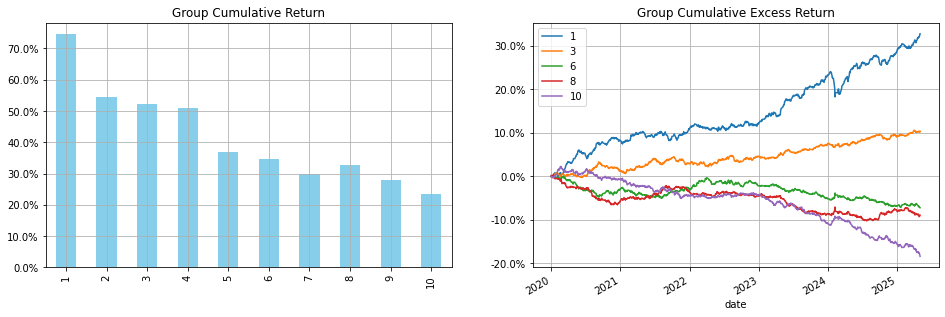

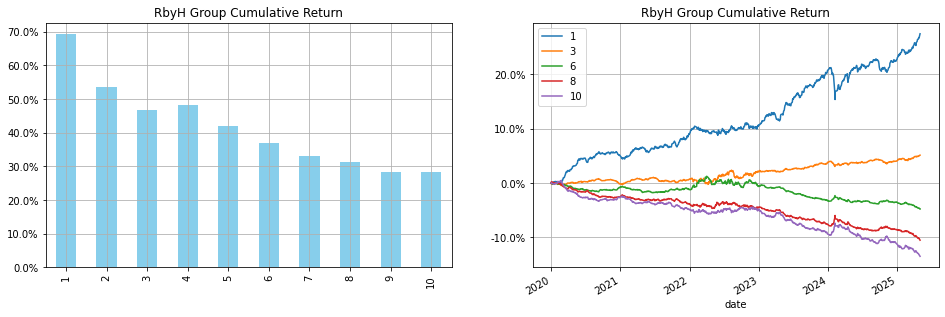

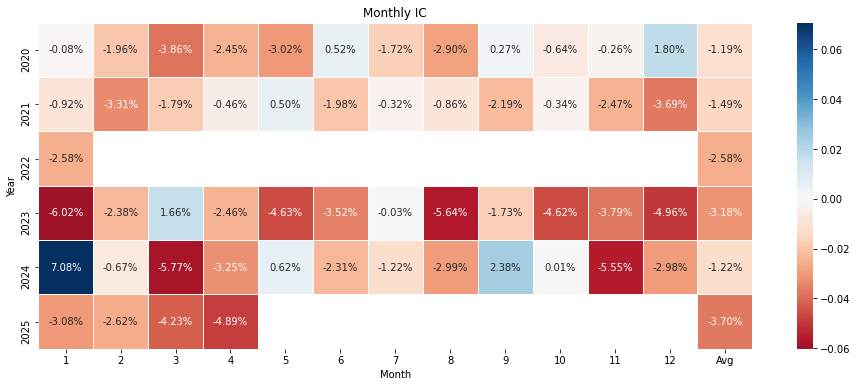

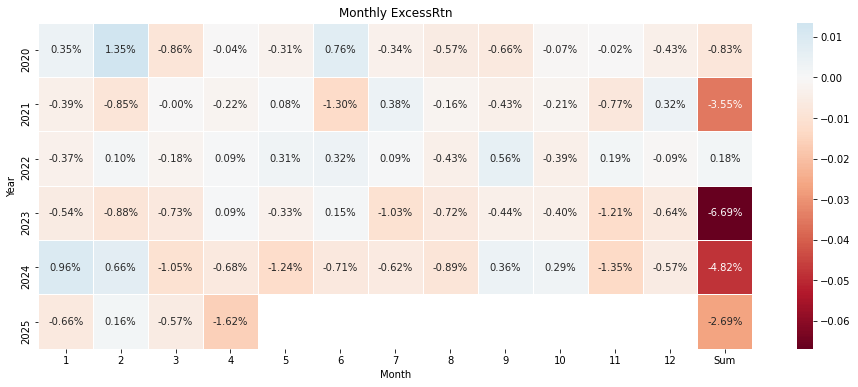

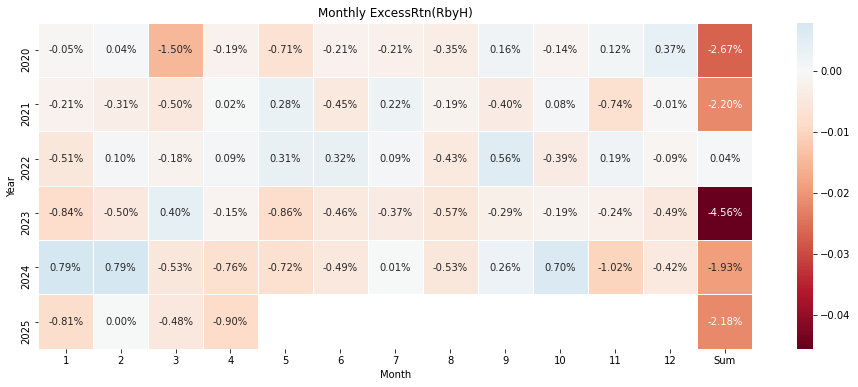

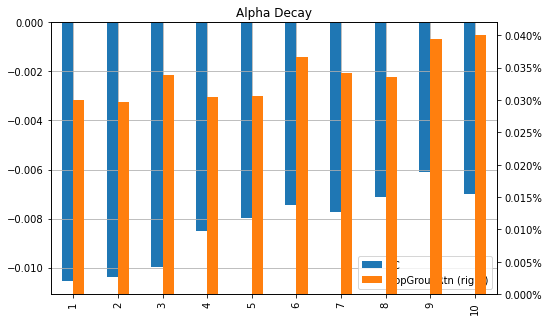

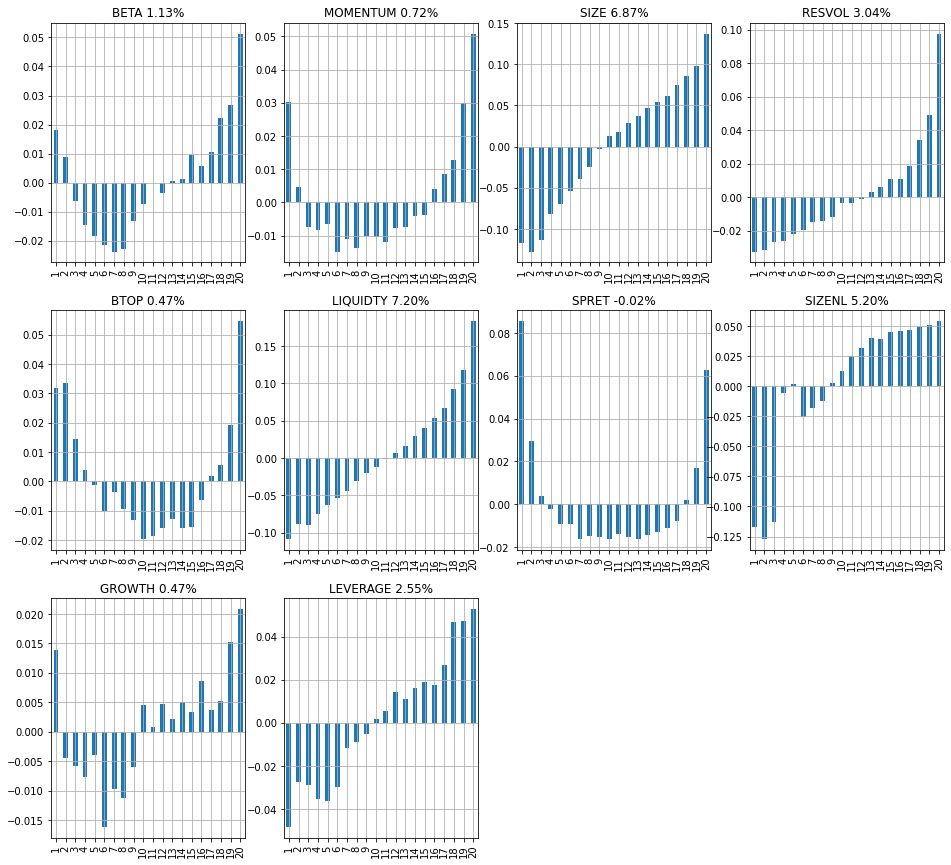


---

## [7/14] 表名: `factor_sum_dead_05`

文件: `factor_sum_dead_05.parquet`  |  参数: if_trade_tmr=True, specific_return=False, return_type=Vwap


  日期范围：2020-01-02 ~ 2026-08-26
  列数（沪深A股）：5458


,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,-1.90%,-0.511,98.9%,20.7%,-9.6%,-2.40,-7.6%,-2.24


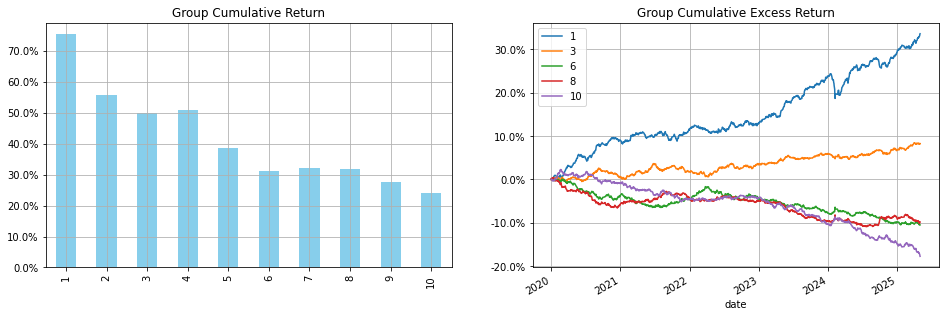

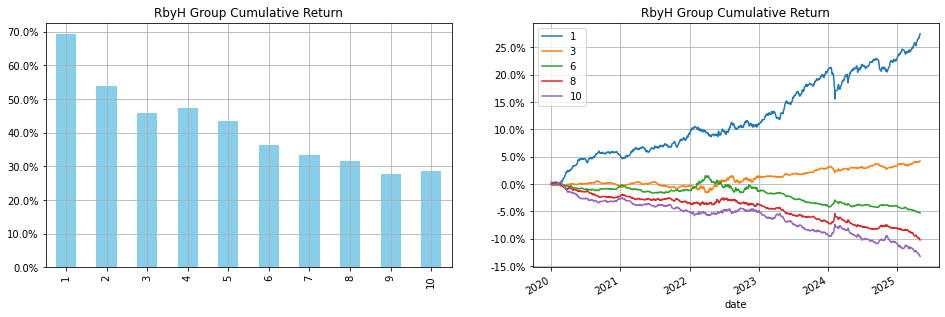

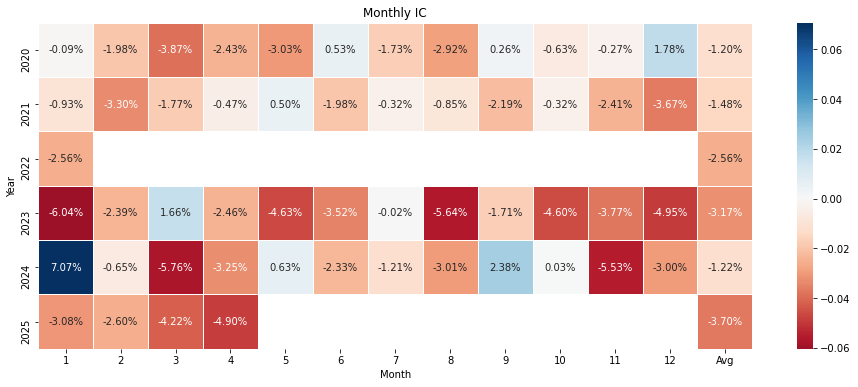

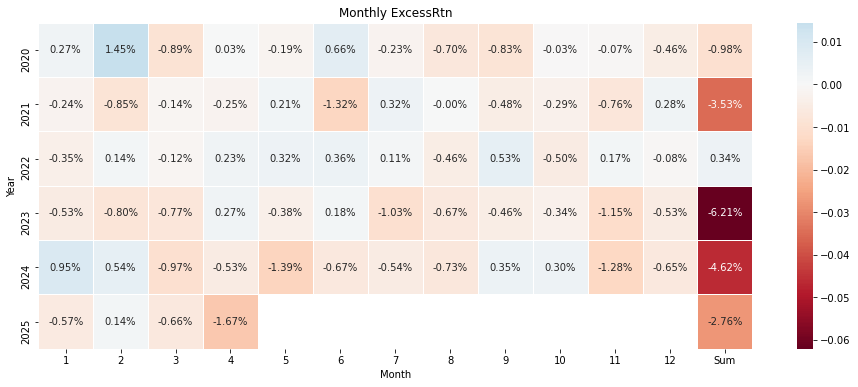

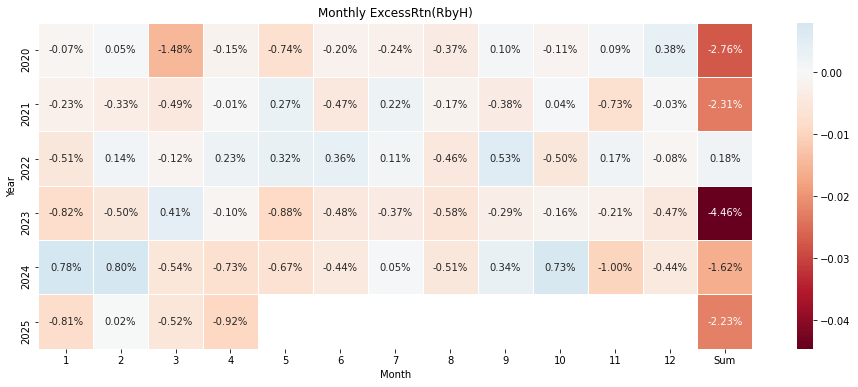

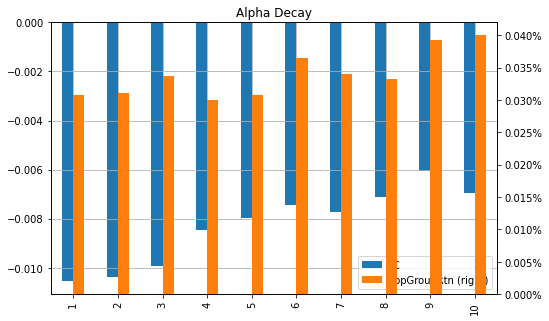

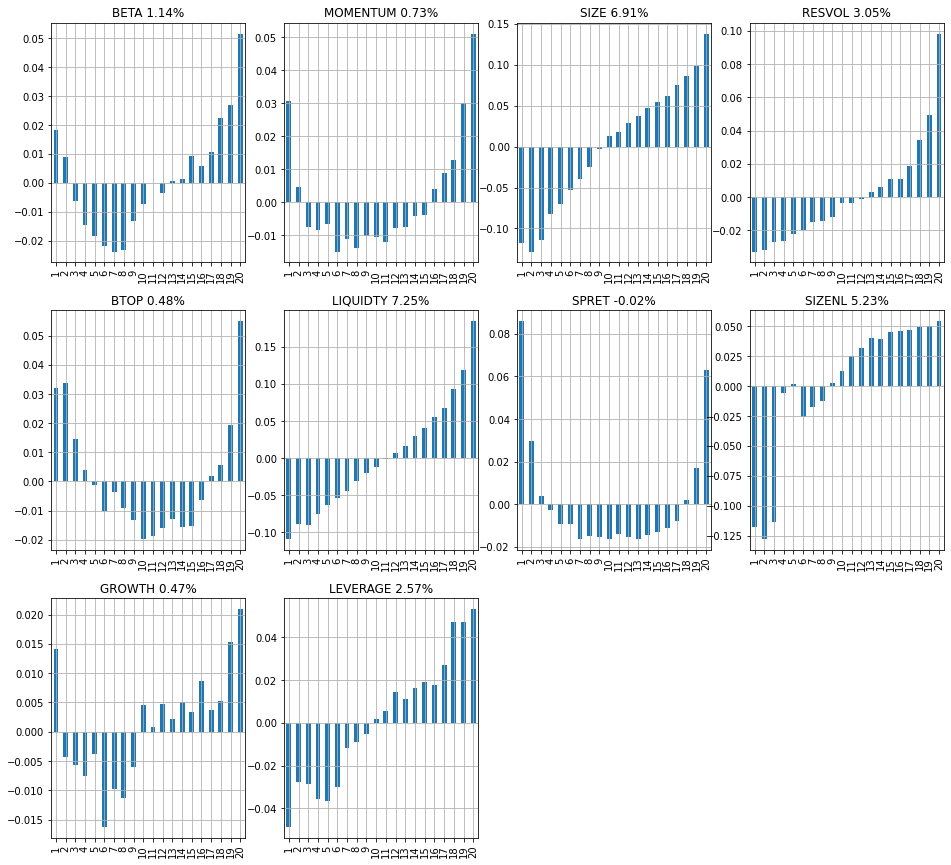


---

## [8/14] 表名: `factor_sum_dead_06`

文件: `factor_sum_dead_06.parquet`  |  参数: if_trade_tmr=True, specific_return=False, return_type=Vwap


  日期范围：2020-01-02 ~ 2026-08-26
  列数（沪深A股）：5458


,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,-1.90%,-0.510,98.9%,20.7%,-9.8%,-2.47,-7.6%,-2.22


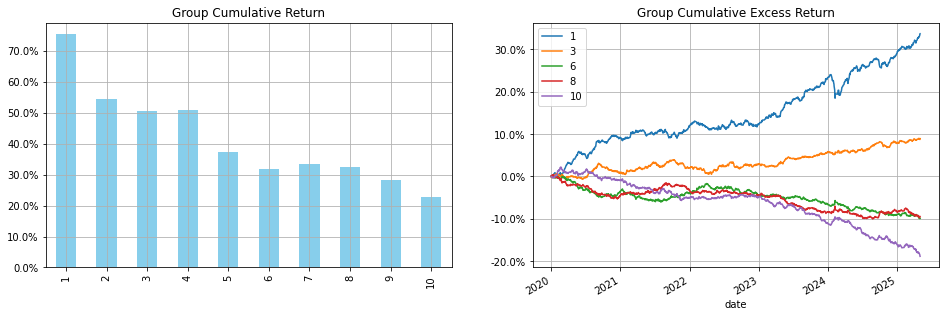

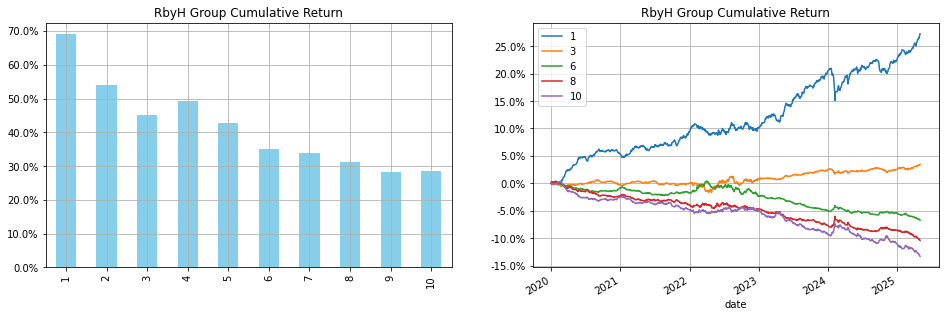

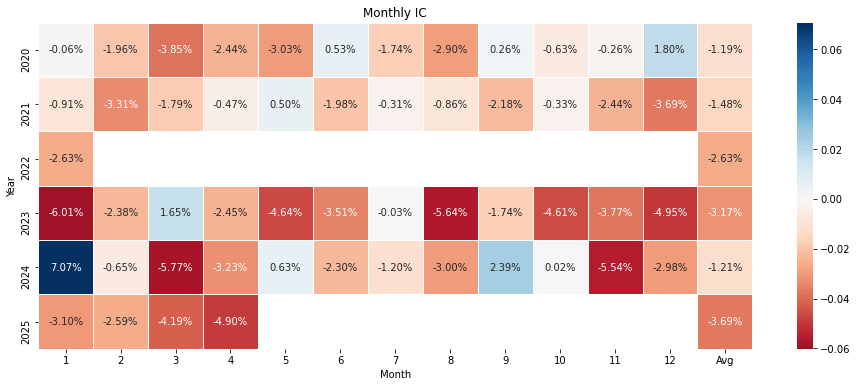

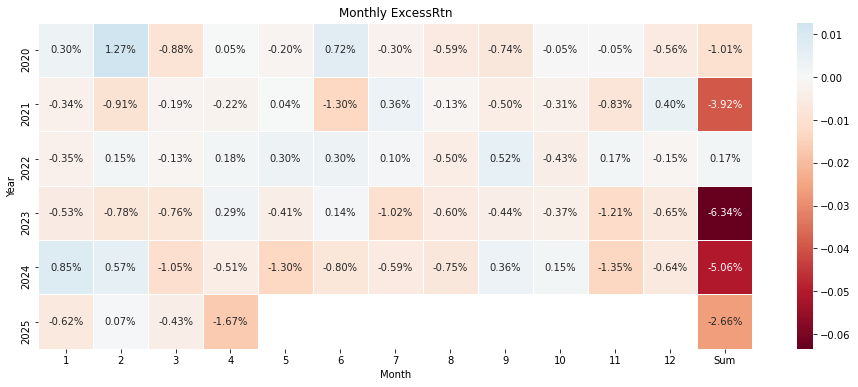

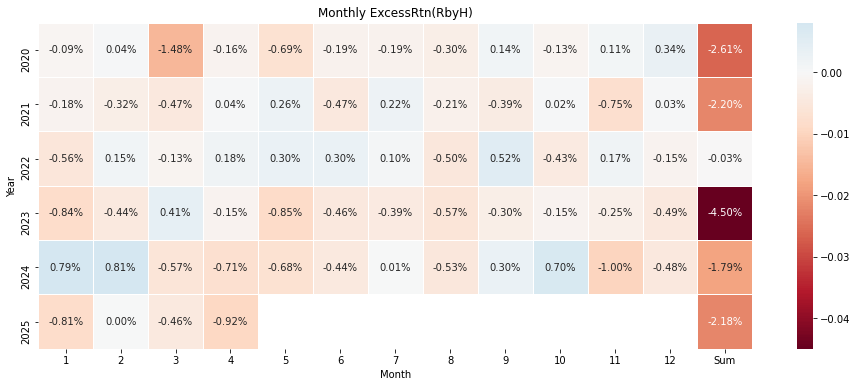

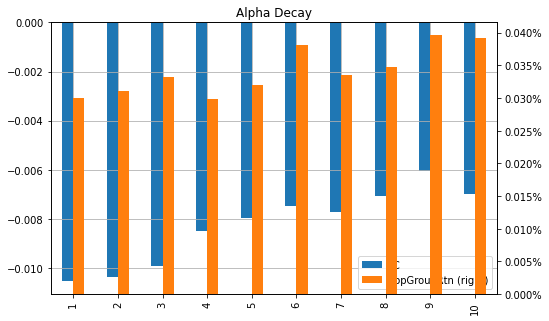

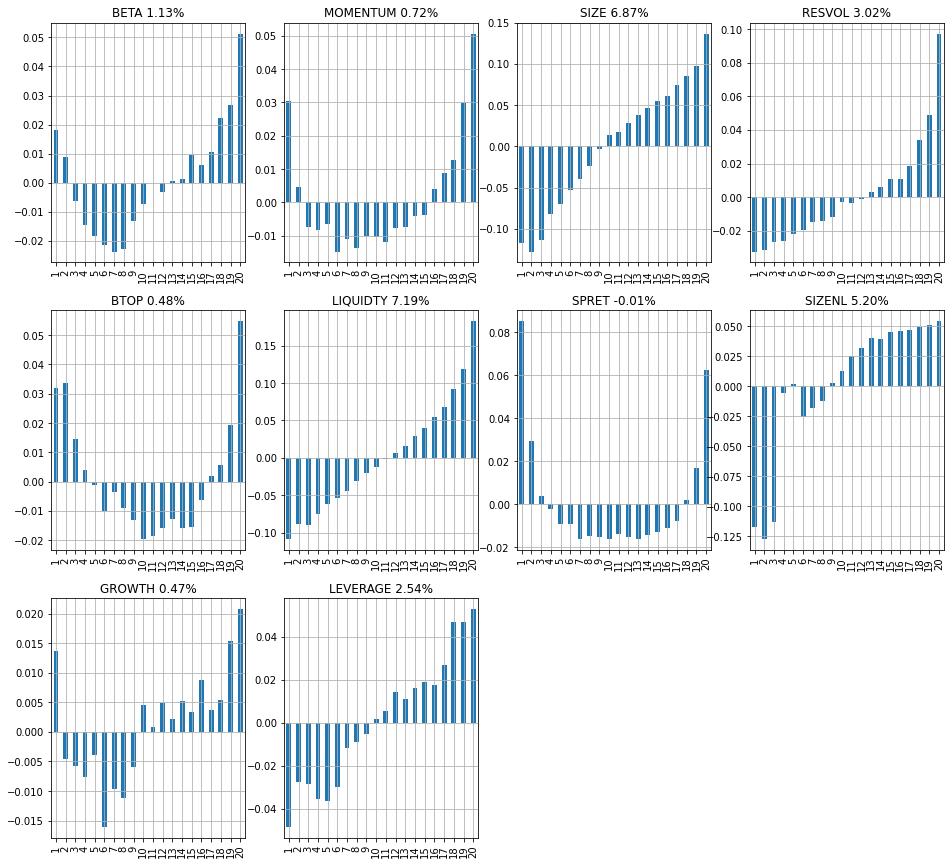


---

## [9/14] 表名: `factor_sum_dead_07`

文件: `factor_sum_dead_07.parquet`  |  参数: if_trade_tmr=True, specific_return=False, return_type=Vwap


  日期范围：2020-01-02 ~ 2026-08-26
  列数（沪深A股）：5458


,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,-1.90%,-0.511,98.9%,20.7%,-9.8%,-2.44,-7.6%,-2.21


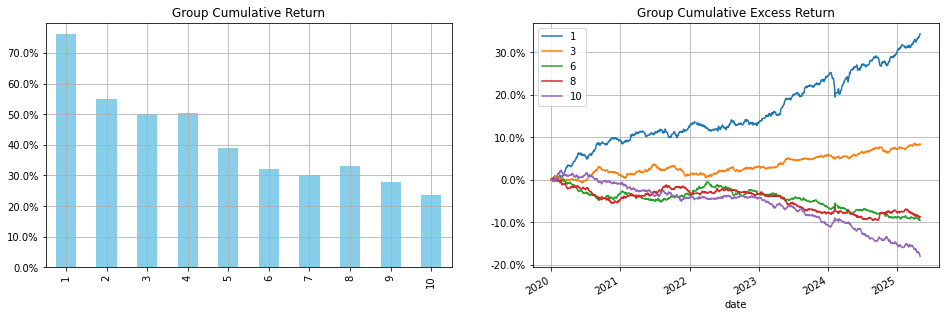

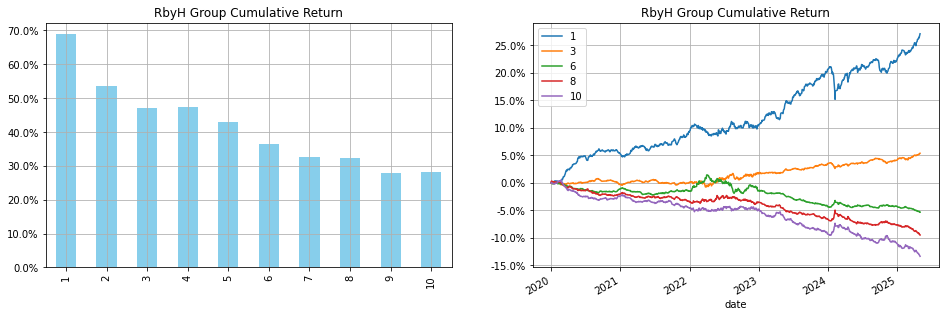

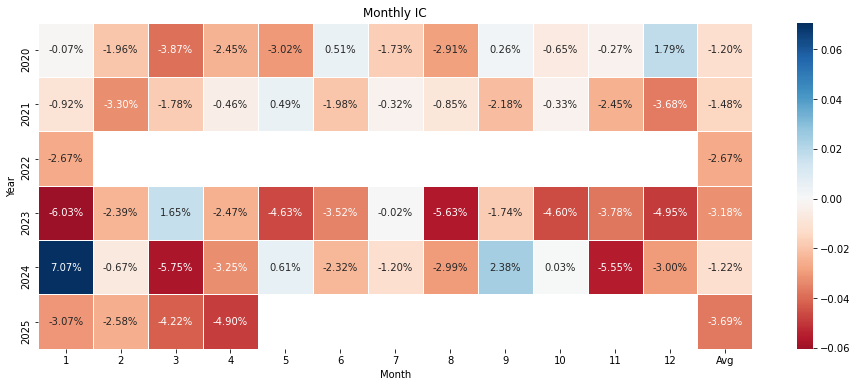

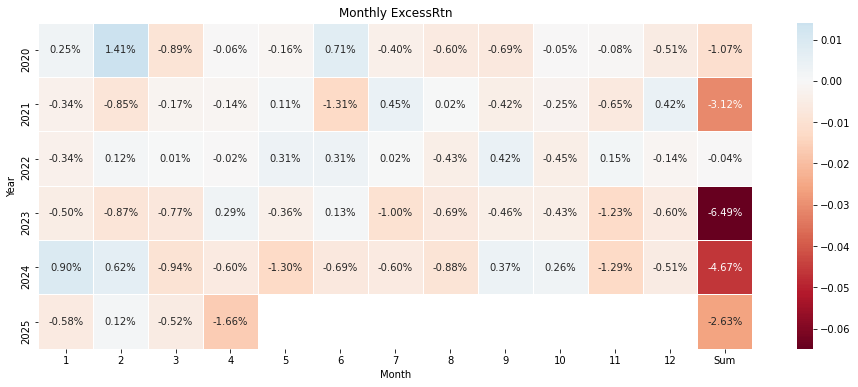

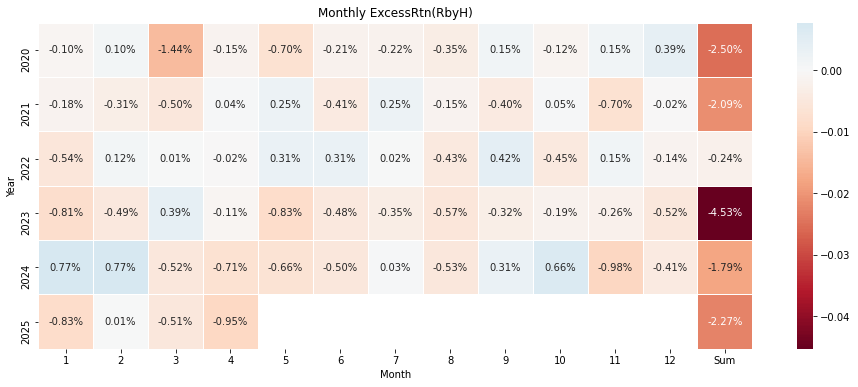

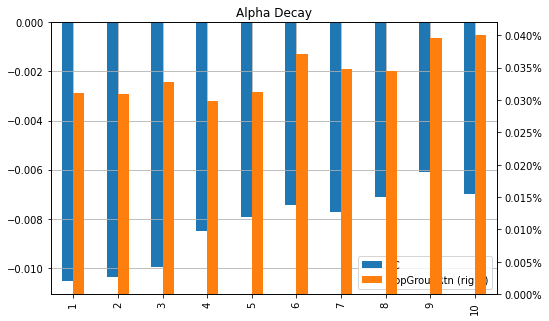

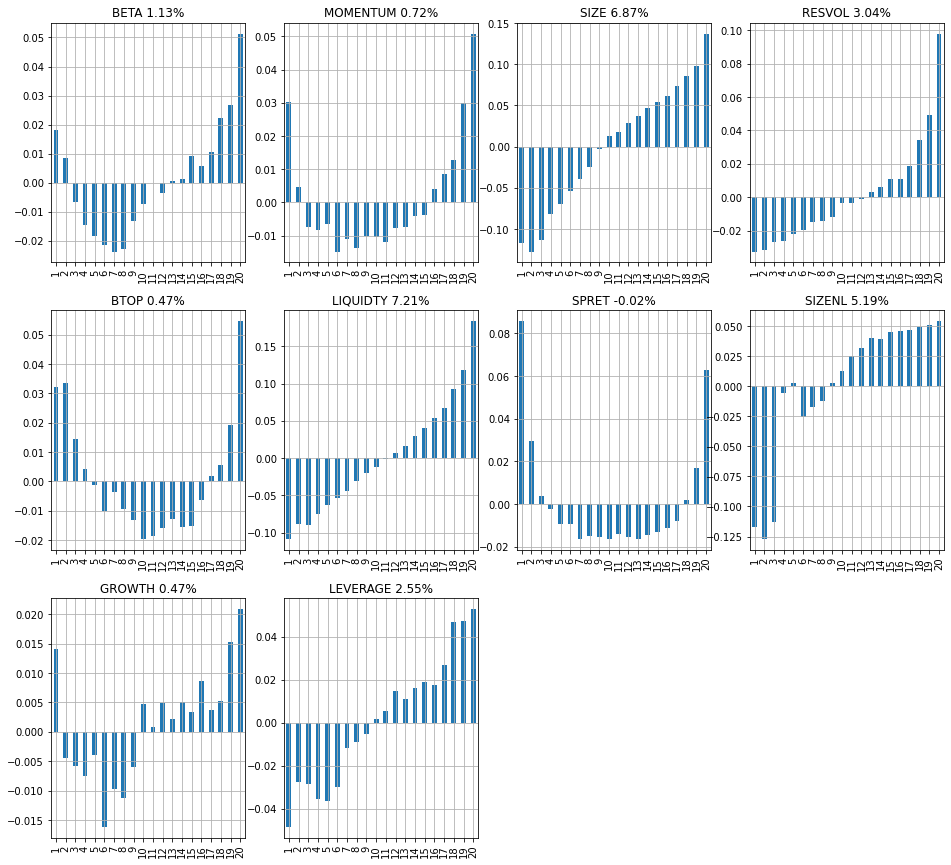


---

## [10/14] 表名: `factor_sum_dead_08`

文件: `factor_sum_dead_08.parquet`  |  参数: if_trade_tmr=True, specific_return=False, return_type=Vwap


  日期范围：2020-01-02 ~ 2026-08-26
  列数（沪深A股）：5458


,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,-1.92%,-0.512,98.9%,20.7%,-9.7%,-2.40,-7.6%,-2.22


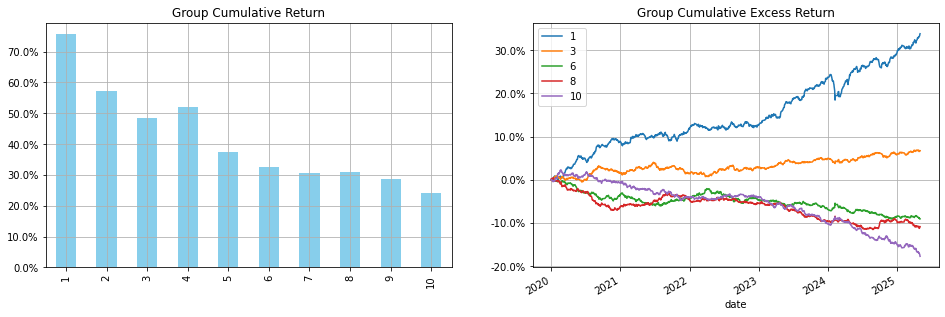

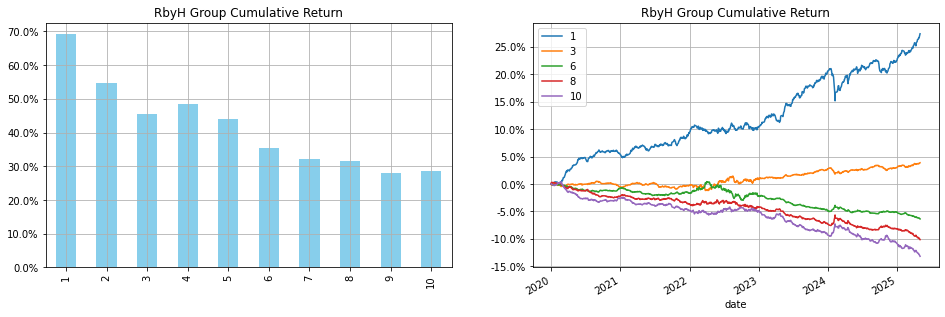

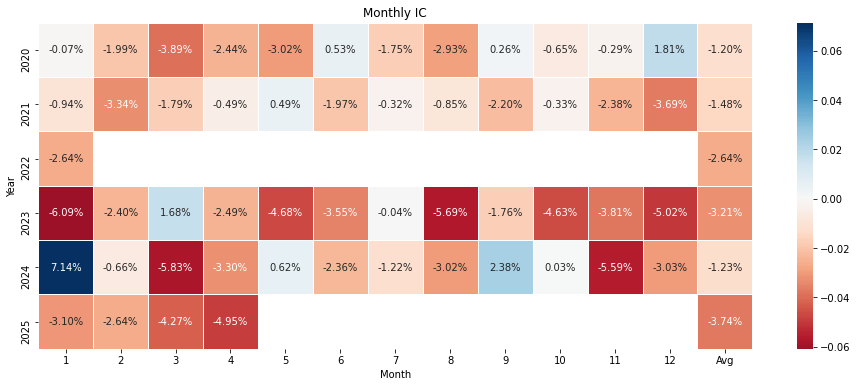

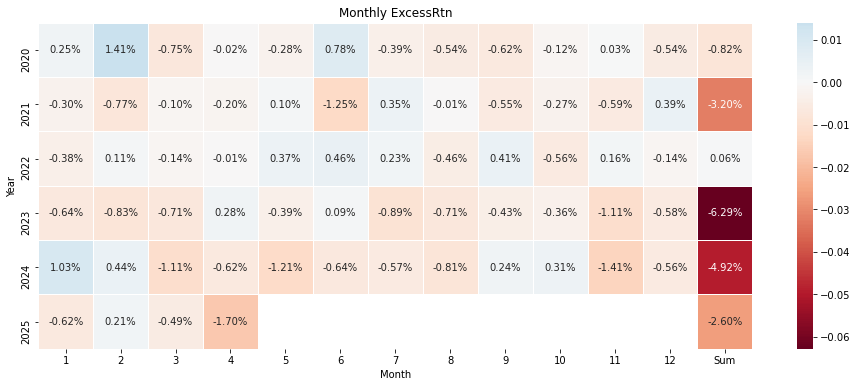

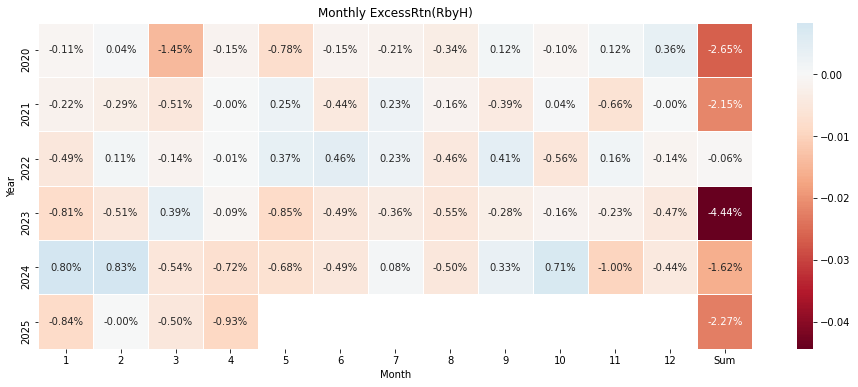

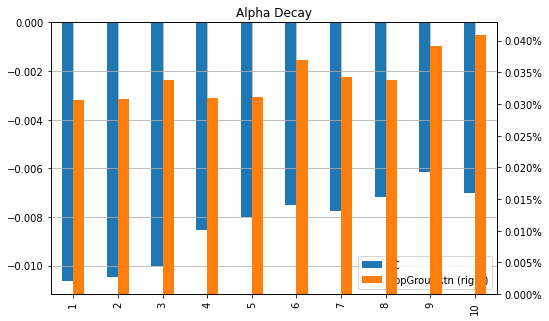

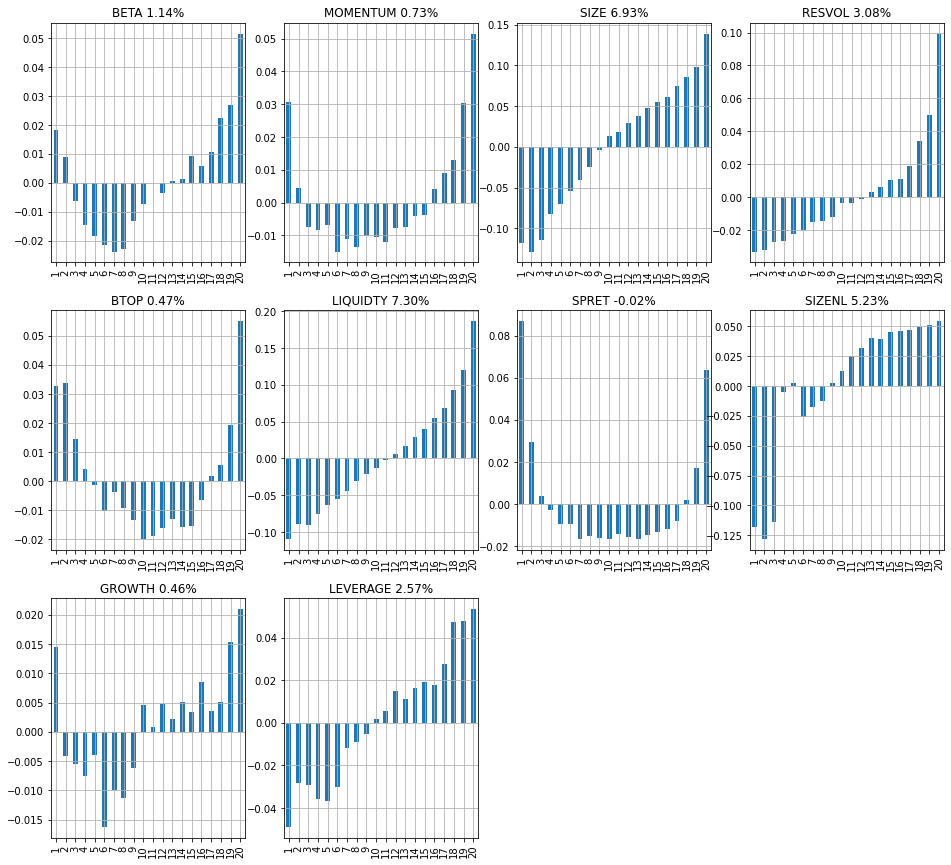


---

## [11/14] 表名: `factor_sum_dead_09`

文件: `factor_sum_dead_09.parquet`  |  参数: if_trade_tmr=True, specific_return=False, return_type=Vwap


  日期范围：2020-01-02 ~ 2026-08-26
  列数（沪深A股）：5458


,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,-1.91%,-0.512,98.9%,20.7%,-10.0%,-2.49,-7.9%,-2.31


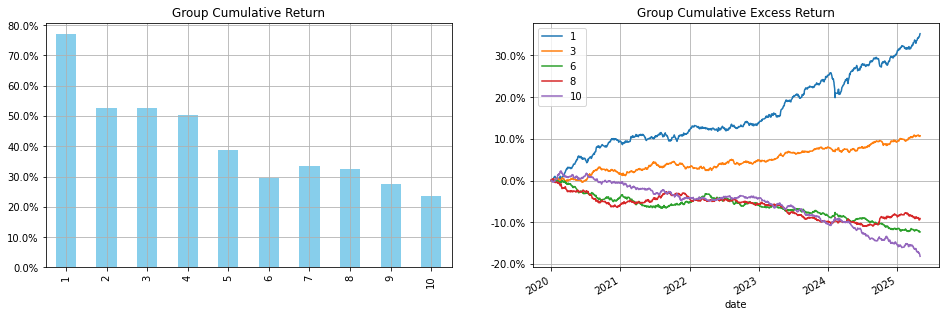

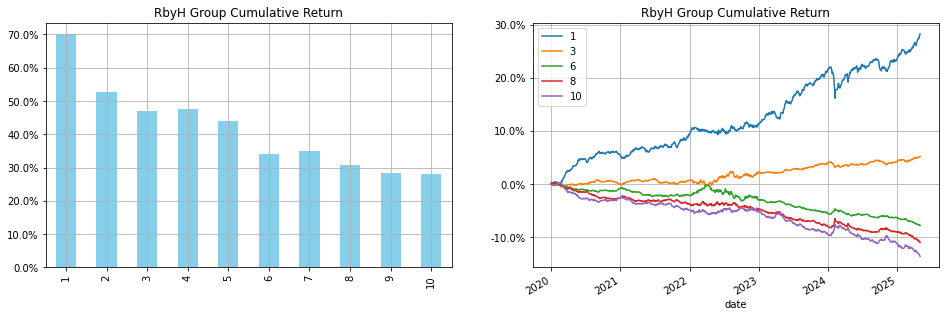

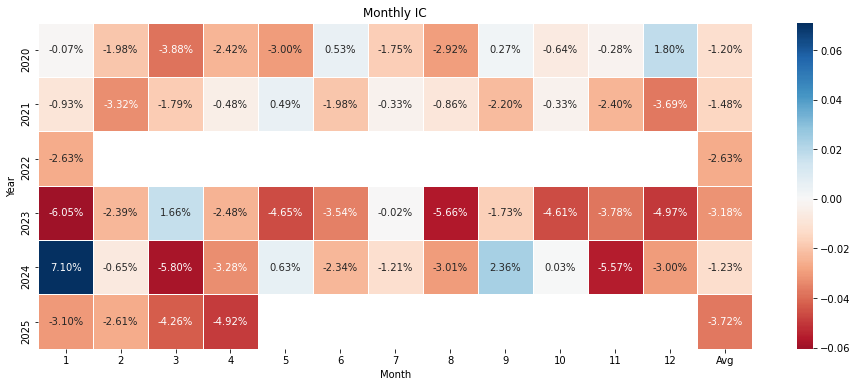

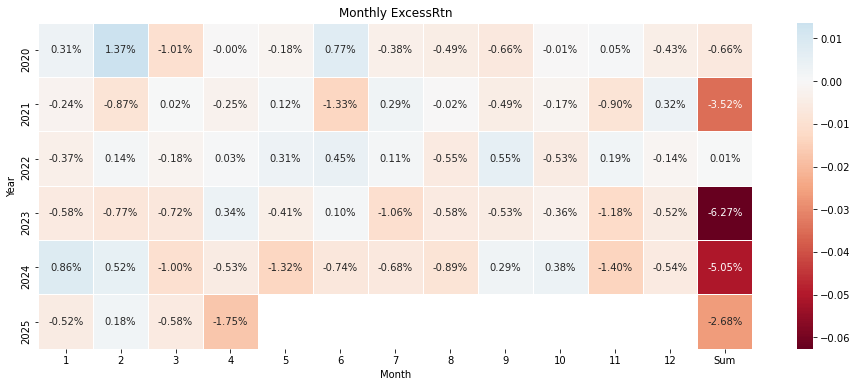

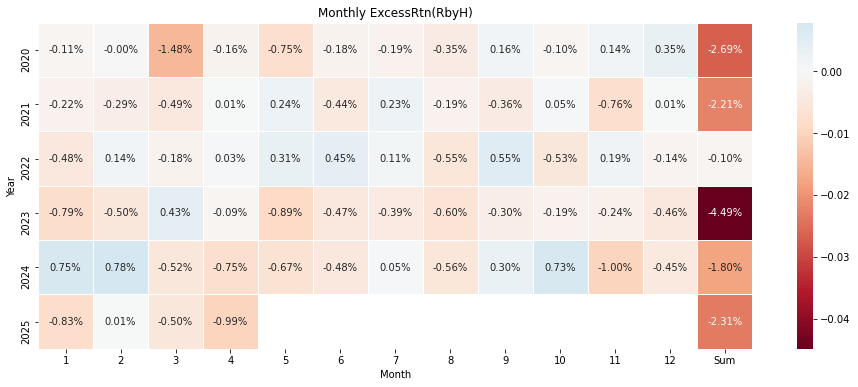

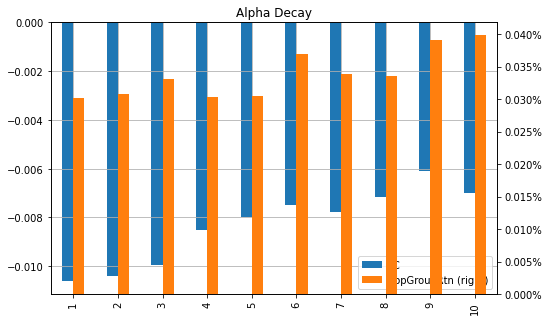

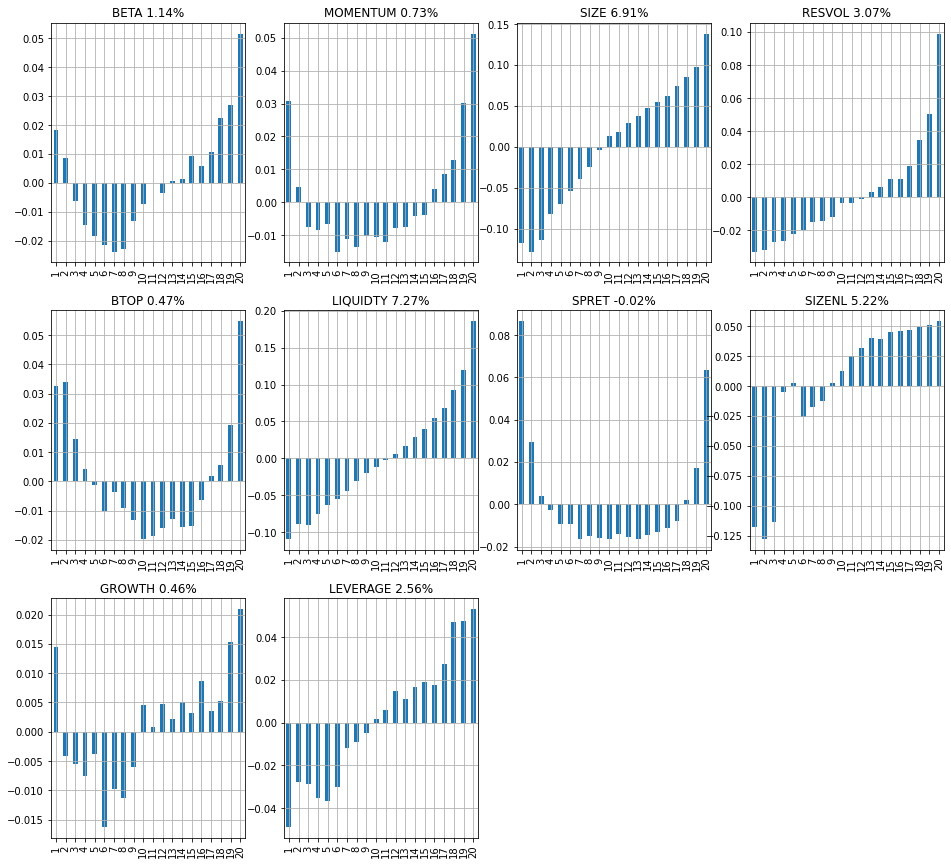


---

## [12/14] 表名: `factor_sum_dead_10`

文件: `factor_sum_dead_10.parquet`  |  参数: if_trade_tmr=True, specific_return=False, return_type=Vwap


  日期范围：2020-01-02 ~ 2026-08-26
  列数（沪深A股）：5458


,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,-1.92%,-0.512,98.9%,20.7%,-10.0%,-2.49,-7.8%,-2.27


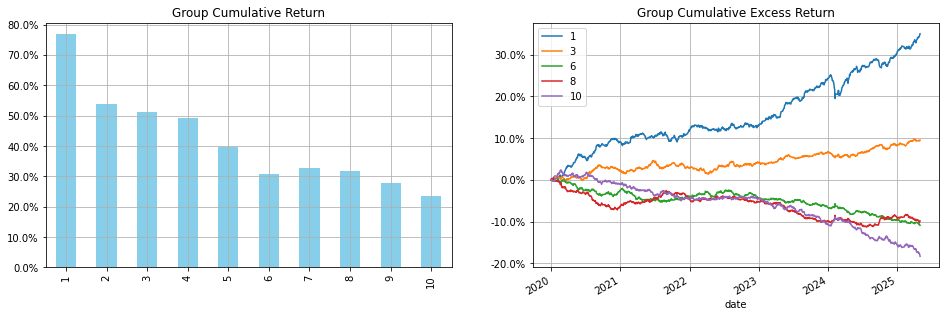

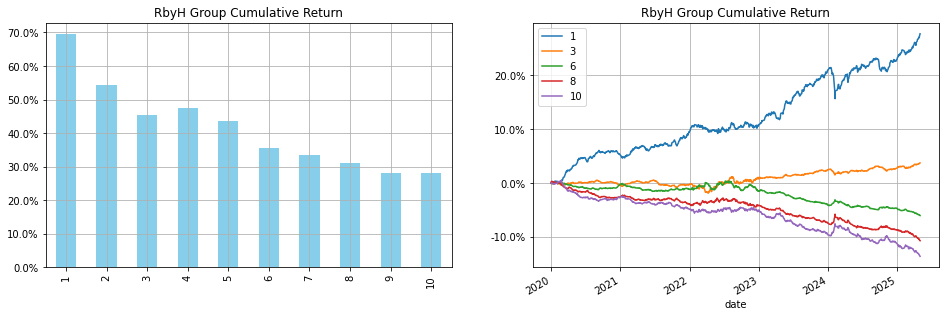

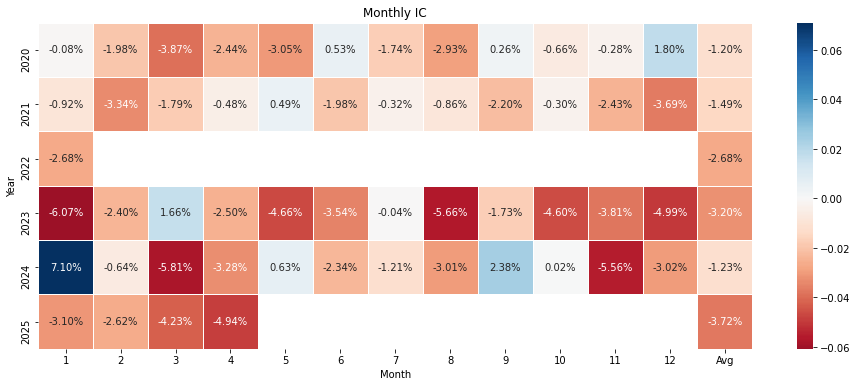

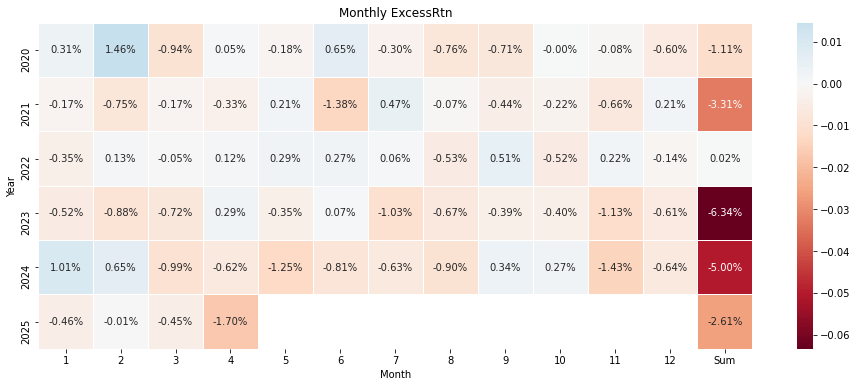

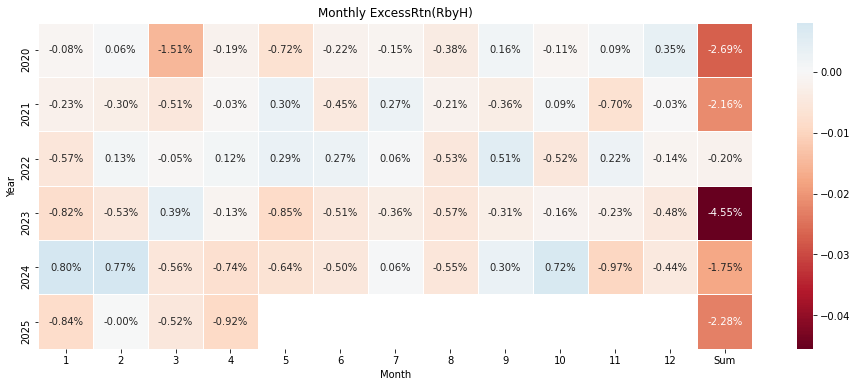

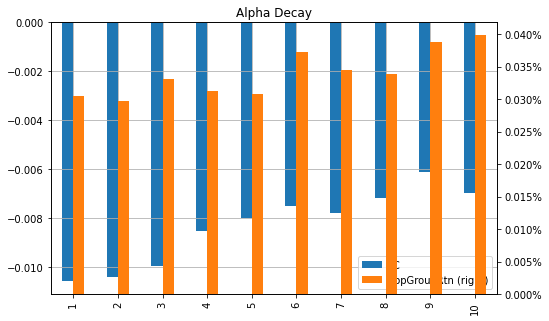

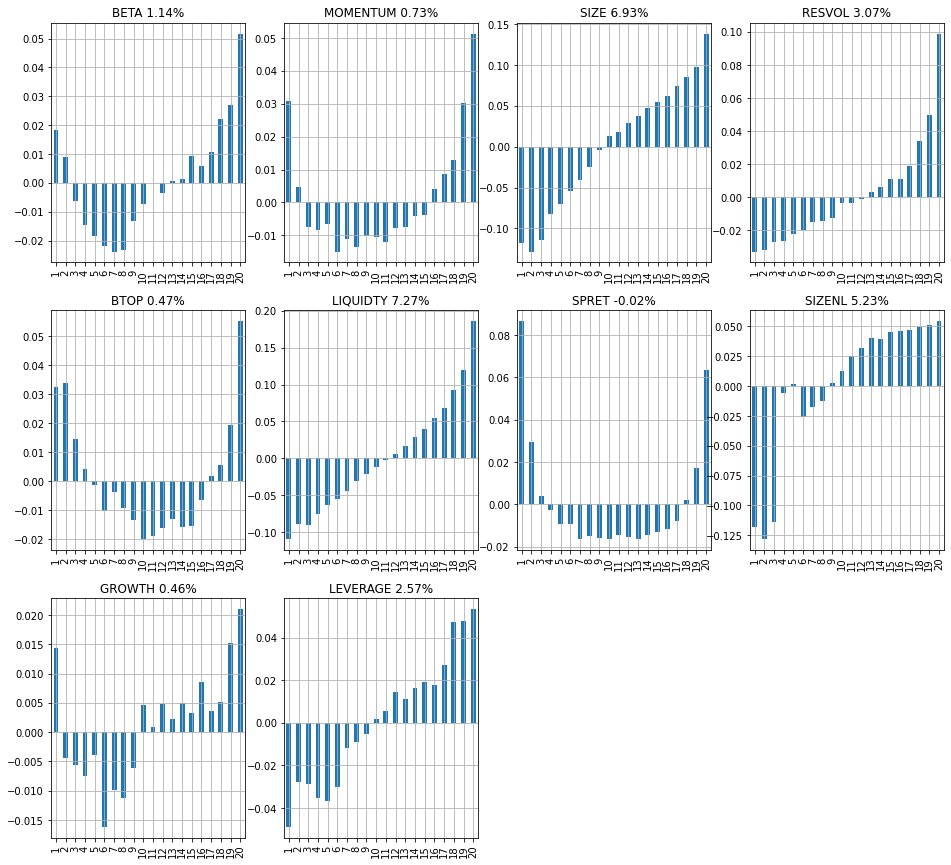


---

## [13/14] 表名: `factor_sum_dead_11`

文件: `factor_sum_dead_11.parquet`  |  参数: if_trade_tmr=True, specific_return=False, return_type=Vwap


  日期范围：2020-01-02 ~ 2026-08-26
  列数（沪深A股）：5458


,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,-1.91%,-0.511,98.9%,20.7%,-9.6%,-2.38,-7.9%,-2.29


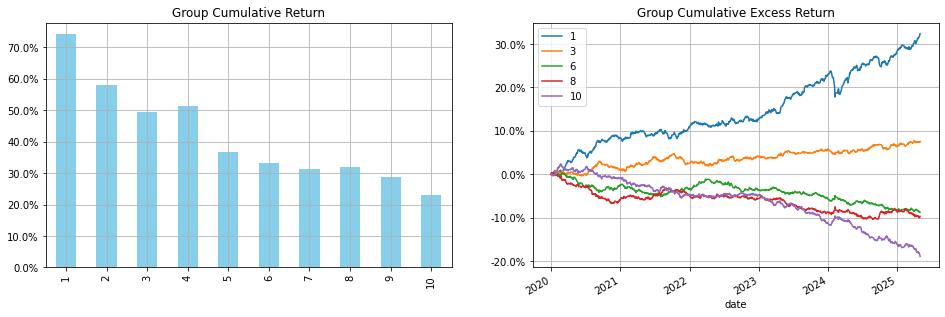

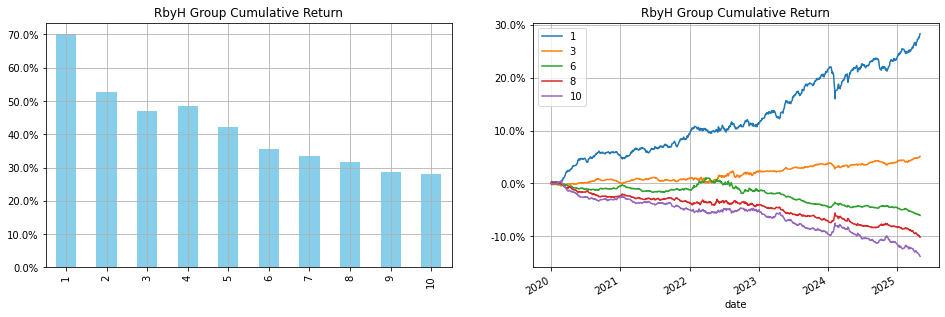

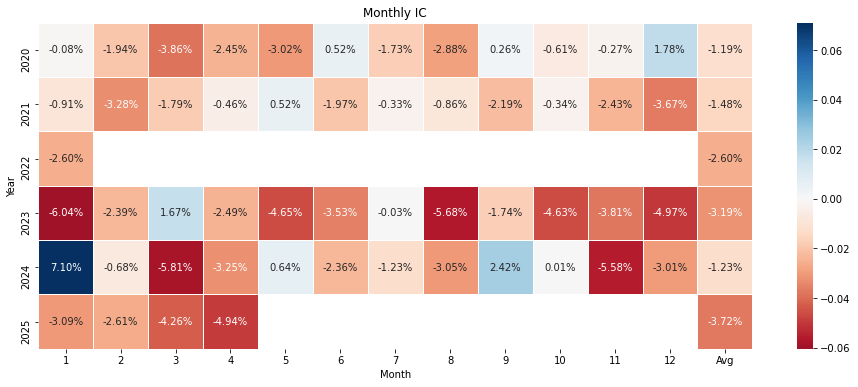

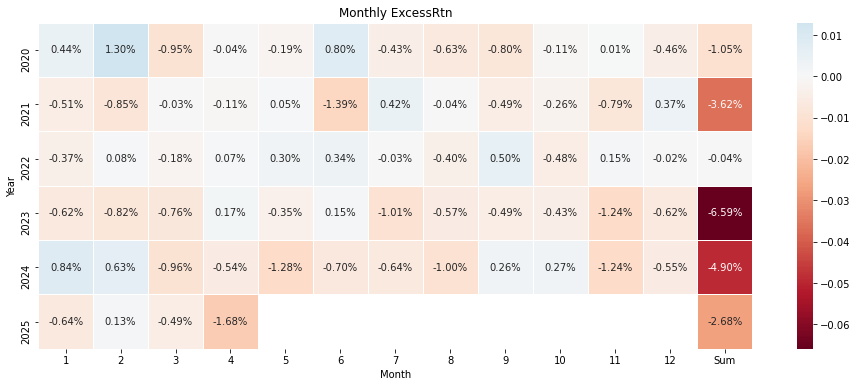

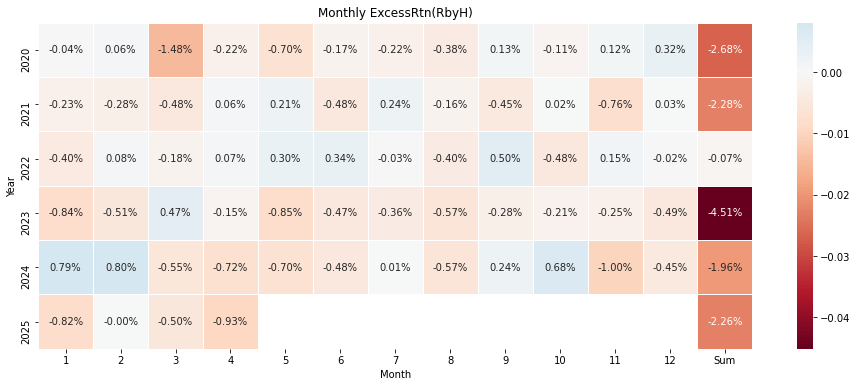

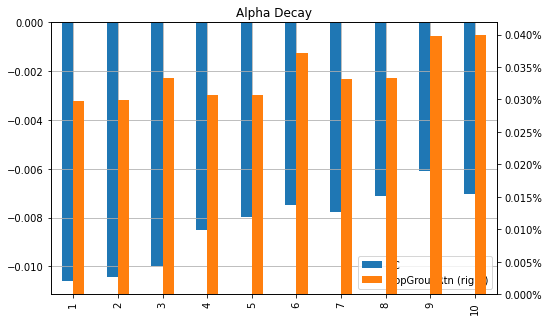

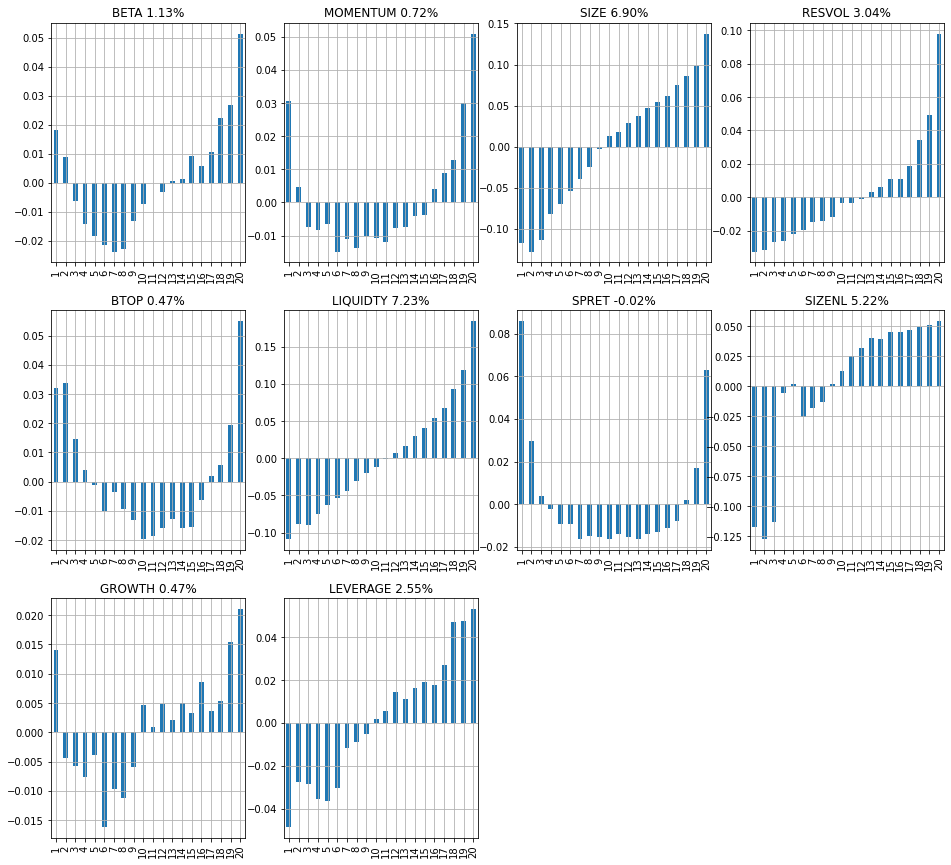


---

## [14/14] 表名: `factor_sum_dead_12`

文件: `factor_sum_dead_12.parquet`  |  参数: if_trade_tmr=True, specific_return=False, return_type=Vwap


  日期范围：2020-01-02 ~ 2026-08-26
  列数（沪深A股）：5458


,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,-1.91%,-0.512,98.9%,20.7%,-9.8%,-2.44,-7.7%,-2.24


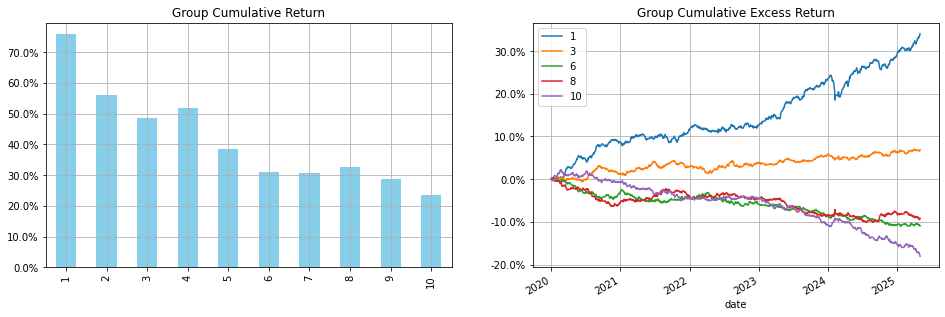

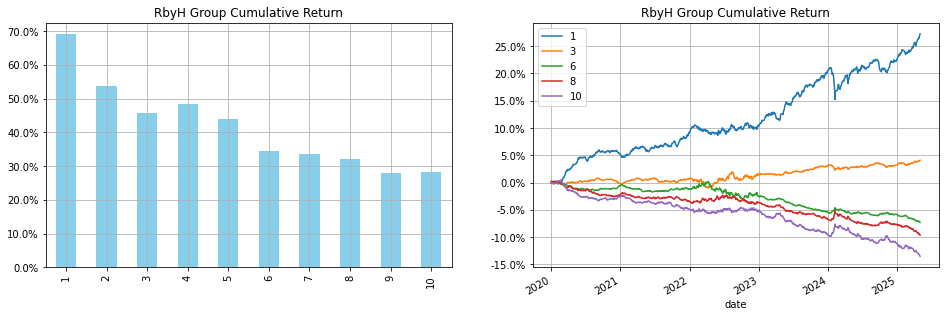

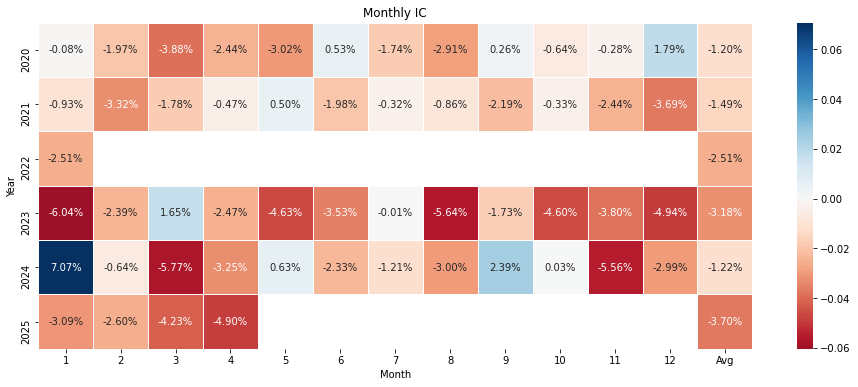

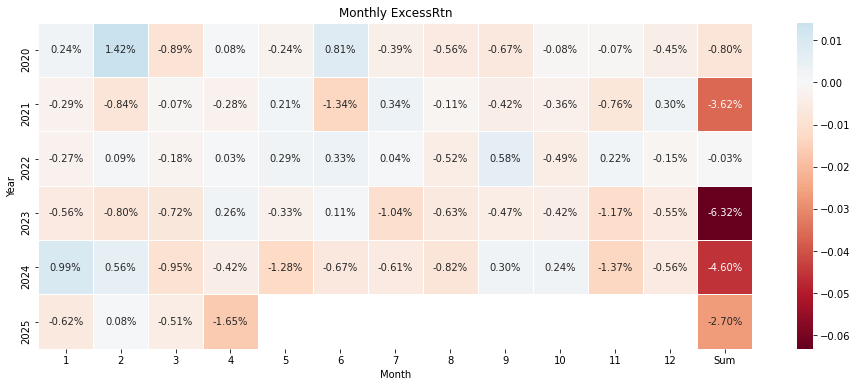

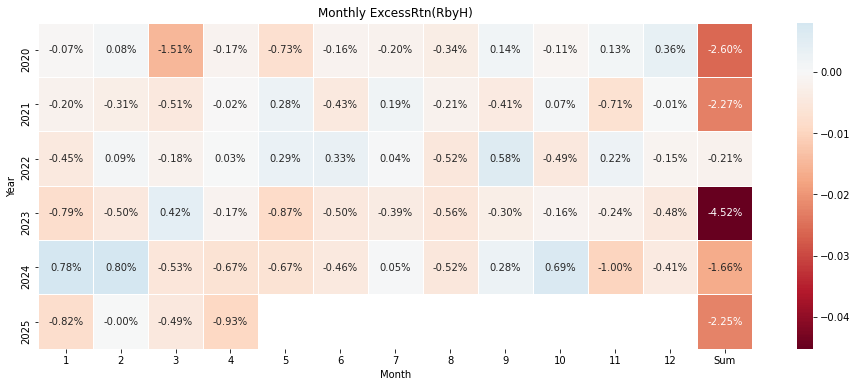

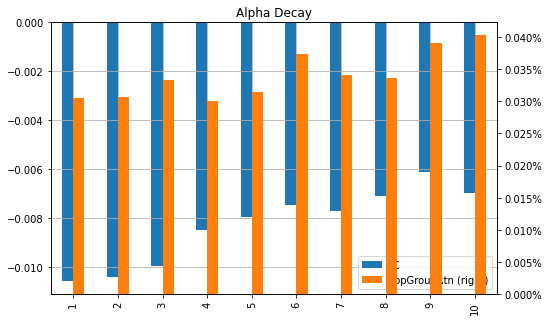

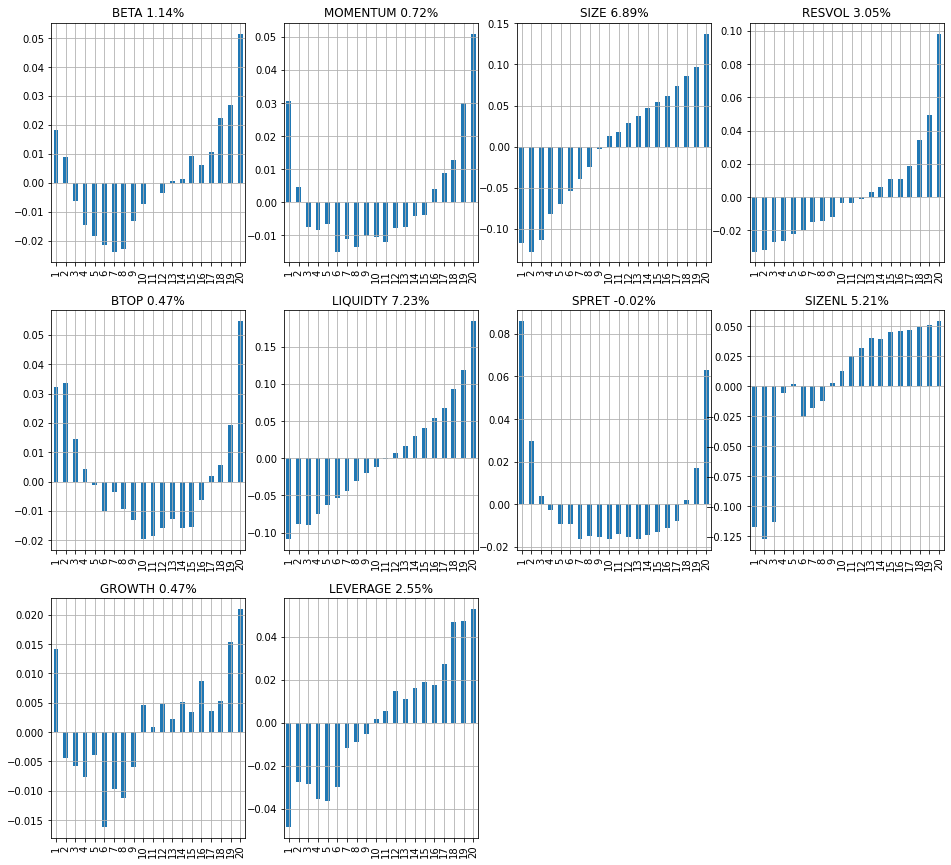



✅ 批量回测完成！


In [6]:
# ============ 批量回测 ============
summary_records = []

for idx, fpath in enumerate(table_files):
    fname      = os.path.basename(fpath)
    table_name = fname.replace(".parquet", "")

    # —— 标注表名 ——
    ipy_display(Markdown(
        f"\n---\n\n## [{idx+1}/{len(table_files)}] 表名: `{table_name}`\n\n"
        f"文件: `{fname}`  |  参数: if_trade_tmr={IF_TRADE_TMR}, "
        f"specific_return={SPECIFIC_RETURN}, return_type={RETURN_TYPE}\n"
    ))

    try:
        factor_wide = load_and_process(fpath)
        res = test_factor(
            factor_wide.dropna(how="all", axis=0),
            start_dt=START_DT,
            end_dt=END_DT,
            display=DISPLAY,
            if_trade_tmr=IF_TRADE_TMR,
            specific_return=SPECIFIC_RETURN,
            return_type=RETURN_TYPE,
        )

        # 提取指标到汇总
        perf = res.Performance_Dict
        record = {"table": table_name}
        for k in ["IC", "ICIR", "Coverage", "AutoCorr",
                   "LS_AnnRtn", "LS_Sharpe", "LS_AnnRtn_RbyH", "LS_Sharpe_RbyH"]:
            record[k] = perf.get(k, None)
        summary_records.append(record)

    except Exception as e:
        print(f"  ❌ 回测失败: {e}")
        summary_records.append({"table": table_name, "error": str(e)})

print("\n\n✅ 批量回测完成！")

## 汇总对比表所有因子表的核心回测指标汇总。

In [7]:
# ============ 汇总表 ============
summary_df = pd.DataFrame(summary_records)

# 格式化百分比列
pct_cols  = ["IC", "Coverage", "AutoCorr", "LS_AnnRtn", "LS_AnnRtn_RbyH"]
float_cols = ["ICIR", "LS_Sharpe", "LS_Sharpe_RbyH"]

for col in pct_cols:
    if col in summary_df.columns:
        summary_df[col] = summary_df[col].apply(
            lambda x: f"{x*100:.2f}%" if pd.notna(x) and isinstance(x, (int, float)) else x
        )
for col in float_cols:
    if col in summary_df.columns:
        summary_df[col] = summary_df[col].apply(
            lambda x: f"{x:.3f}" if pd.notna(x) and isinstance(x, (int, float)) else x
        )

print(f"回测参数: if_trade_tmr={IF_TRADE_TMR}, specific_return={SPECIFIC_RETURN}, return_type={RETURN_TYPE}")
print(f"日期范围: {START_DT} ~ {END_DT}")
print(f"表数: {len(table_files)}\n")

summary_df

回测参数: if_trade_tmr=True, specific_return=False, return_type=Vwap
日期范围: 2020.01.03 ~ 2025.05.01
表数: 14



,table,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,factor_sum_H,-1.90%,-0.511,98.90%,20.74%,-9.65%,-2.408,-7.70%,-2.244
1,factor_sum_L,-1.91%,-0.512,98.90%,20.75%,-9.56%,-2.385,-7.74%,-2.272
2,factor_sum_dead_01,-1.91%,-0.512,98.90%,20.74%,-9.81%,-2.444,-7.68%,-2.246
3,factor_sum_dead_02,-1.91%,-0.511,98.90%,20.73%,-9.57%,-2.393,-7.66%,-2.239
4,factor_sum_dead_03,-1.91%,-0.512,98.90%,20.73%,-9.63%,-2.404,-7.68%,-2.257
5,factor_sum_dead_04,-1.91%,-0.511,98.90%,20.71%,-9.60%,-2.414,-7.69%,-2.269
6,factor_sum_dead_05,-1.90%,-0.511,98.90%,20.73%,-9.65%,-2.400,-7.64%,-2.240
7,factor_sum_dead_06,-1.90%,-0.510,98.90%,20.71%,-9.85%,-2.467,-7.62%,-2.220
8,factor_sum_dead_07,-1.90%,-0.511,98.90%,20.71%,-9.82%,-2.442,-7.61%,-2.211
9,factor_sum_dead_08,-1.92%,-0.512,98.90%,20.74%,-9.68%,-2.402,-7.62%,-2.224
